# CISI Future Projections
Runs the trained CNN on SSP scenario inputs for 2030, 2050, and 2100.
Fill in the file paths marked `# TODO` before running.

In [81]:
import numpy as np
import torch
import torch.nn as nn
import rasterio
from rasterio.enums import Resampling
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import geopandas as gpd
from pathlib import Path
import os

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

Device: cpu


In [82]:
class CNNSweep(nn.Module):
    def __init__(self, config):
        super().__init__()
        d = config.get('dropout', 0.3)
        n_layers = config.get('n_layers', 4)
        base_ch  = config.get('base_channels', 16)
        layers = []; in_ch = 9; out_ch = base_ch
        for i in range(n_layers):
            layers += [nn.Conv2d(in_ch, out_ch, 3, padding=1),
                       nn.BatchNorm2d(out_ch), nn.ReLU(), nn.Dropout(d)]
            if i < n_layers - 1:
                layers.append(nn.MaxPool2d(2, 2))
            in_ch = out_ch; out_ch = min(out_ch * 2, 256)
        self.conv_layers = nn.Sequential(*layers)
        self.fc_layers   = nn.Sequential(
            nn.Linear(in_ch, 32), nn.BatchNorm1d(32),
            nn.ReLU(), nn.Dropout(d), nn.Linear(32, 1))

    def forward(self, x):
        x = self.conv_layers(x)
        x = x[:, :, 1, 1]
        return torch.sigmoid(self.fc_layers(x))


## Paths fill in before running

In [83]:
MODEL_PATH  = 'final_model_lilac56.pt'
OUTPUT_DIR  = 'projections_output'   # GeoTIFFs
FIGURES_DIR = 'projections_output'   # figures — same folder

REFERENCE_RASTER = r'READY_data\labels\2024_CISI_010deg_nearest.tif'
SHP_PATH         = r'ne_10m_admin_0_countries\ne_10m_admin_0_countries.shp'

os.makedirs(OUTPUT_DIR,  exist_ok=True)

NORM_DIR = r'READY_data\inputs_normalized\ssp'

SCENARIOS = {
    'SSP1': {
        2030: {
            'gdp': rf'{NORM_DIR}\GDP_SSP1_2030_normalized.tif',
            'pop': rf'{NORM_DIR}\POP_SSP1_2030_normalized.tif',
            'lc':  [rf'{NORM_DIR}\LC_SSP1_2030_class_{c}.tif' for c in range(1, 8)],
        },
        2050: {
            'gdp': rf'{NORM_DIR}\GDP_SSP1_2050_normalized.tif',
            'pop': rf'{NORM_DIR}\POP_SSP1_2050_normalized.tif',
            'lc':  [rf'{NORM_DIR}\LC_SSP1_2050_class_{c}.tif' for c in range(1, 8)],
        },
        2100: {
            'gdp': rf'{NORM_DIR}\GDP_SSP1_2100_normalized.tif',
            'pop': rf'{NORM_DIR}\POP_SSP1_2100_normalized.tif',
            'lc':  [rf'{NORM_DIR}\LC_SSP1_2100_class_{c}.tif' for c in range(1, 8)],
        },
    },
    'SSP2': {
        2030: {
            'gdp': rf'{NORM_DIR}\GDP_SSP2_2030_normalized.tif',
            'pop': rf'{NORM_DIR}\POP_SSP2_2030_normalized.tif',
            'lc':  [rf'{NORM_DIR}\LC_SSP2_2030_class_{c}.tif' for c in range(1, 8)],
        },
        2050: {
            'gdp': rf'{NORM_DIR}\GDP_SSP2_2050_normalized.tif',
            'pop': rf'{NORM_DIR}\POP_SSP2_2050_normalized.tif',
            'lc':  [rf'{NORM_DIR}\LC_SSP2_2050_class_{c}.tif' for c in range(1, 8)],
        },
        2100: {
            'gdp': rf'{NORM_DIR}\GDP_SSP2_2100_normalized.tif',
            'pop': rf'{NORM_DIR}\POP_SSP2_2100_normalized.tif',
            'lc':  [rf'{NORM_DIR}\LC_SSP2_2100_class_{c}.tif' for c in range(1, 8)],
        },
    },
    'SSP3': {
        2030: {
            'gdp': rf'{NORM_DIR}\GDP_SSP3_2030_normalized.tif',
            'pop': rf'{NORM_DIR}\POP_SSP3_2030_normalized.tif',
            'lc':  [rf'{NORM_DIR}\LC_SSP3_2030_class_{c}.tif' for c in range(1, 8)],
        },
        2050: {
            'gdp': rf'{NORM_DIR}\GDP_SSP3_2050_normalized.tif',
            'pop': rf'{NORM_DIR}\POP_SSP3_2050_normalized.tif',
            'lc':  [rf'{NORM_DIR}\LC_SSP3_2050_class_{c}.tif' for c in range(1, 8)],
        },
        2100: {
            'gdp': rf'{NORM_DIR}\GDP_SSP3_2100_normalized.tif',
            'pop': rf'{NORM_DIR}\POP_SSP3_2100_normalized.tif',
            'lc':  [rf'{NORM_DIR}\LC_SSP3_2100_class_{c}.tif' for c in range(1, 8)],
        },
    },
    'SSP4': {
        2030: {
            'gdp': rf'{NORM_DIR}\GDP_SSP4_2030_normalized.tif',
            'pop': rf'{NORM_DIR}\POP_SSP4_2030_normalized.tif',
            'lc':  [rf'{NORM_DIR}\LC_SSP4_2030_class_{c}.tif' for c in range(1, 8)],
        },
        2050: {
            'gdp': rf'{NORM_DIR}\GDP_SSP4_2050_normalized.tif',
            'pop': rf'{NORM_DIR}\POP_SSP4_2050_normalized.tif',
            'lc':  [rf'{NORM_DIR}\LC_SSP4_2050_class_{c}.tif' for c in range(1, 8)],
        },
        2100: {
            'gdp': rf'{NORM_DIR}\GDP_SSP4_2100_normalized.tif',
            'pop': rf'{NORM_DIR}\POP_SSP4_2100_normalized.tif',
            'lc':  [rf'{NORM_DIR}\LC_SSP4_2100_class_{c}.tif' for c in range(1, 8)],
        },
    },
    'SSP5': {
        2030: {
            'gdp': rf'{NORM_DIR}\GDP_SSP5_2030_normalized.tif',
            'pop': rf'{NORM_DIR}\POP_SSP5_2030_normalized.tif',
            'lc':  [rf'{NORM_DIR}\LC_SSP5_2030_class_{c}.tif' for c in range(1, 8)],
        },
        2050: {
            'gdp': rf'{NORM_DIR}\GDP_SSP5_2050_normalized.tif',
            'pop': rf'{NORM_DIR}\POP_SSP5_2050_normalized.tif',
            'lc':  [rf'{NORM_DIR}\LC_SSP5_2050_class_{c}.tif' for c in range(1, 8)],
        },
        2100: {
            'gdp': rf'{NORM_DIR}\GDP_SSP5_2100_normalized.tif',
            'pop': rf'{NORM_DIR}\POP_SSP5_2100_normalized.tif',
            'lc':  [rf'{NORM_DIR}\LC_SSP5_2100_class_{c}.tif' for c in range(1, 8)],
        },
    },
}

## Load model

In [84]:
ckpt = torch.load(MODEL_PATH, map_location=device)
projection_model = CNNSweep(ckpt['config']).to(device)
projection_model.load_state_dict(ckpt['model_state_dict'])
projection_model.eval()
print(f'Loaded {MODEL_PATH}')
print(f'Config: {ckpt["config"]}')

Loaded final_model_lilac56.pt
Config: {'patch_size': 8, 'base_channels': 32, 'n_layers': 2, 'loss_fn': 'huber', 'delta': 0.05, 'lr': 0.00018672478544905867, 'weight_decay': 2.5576212047230037e-06, 'dropout': 0.1, 'batch_size': 32}


## Helper: load and align raster to reference grid

In [85]:
def load_aligned(path, ref_shape, ref_transform, ref_crs):
    with rasterio.open(path) as src:
        data = src.read().astype(np.float32)
    if (data.shape[1], data.shape[2]) != ref_shape:
        raise ValueError(f'Shape mismatch in {os.path.basename(path)}: {data.shape[1:]} != {ref_shape}')
    return data


def build_input_stack(gdp_path, pop_path, lc_paths, ref_shape, ref_transform, ref_crs):
    gdp = load_aligned(gdp_path, ref_shape, ref_transform, ref_crs)[0]
    pop = load_aligned(pop_path, ref_shape, ref_transform, ref_crs)[0]
    lc  = np.concatenate([load_aligned(p, ref_shape, ref_transform, ref_crs) for p in lc_paths], axis=0)
    stack = np.stack([gdp, pop, *lc], axis=0)
    return np.nan_to_num(stack, nan=0.0)


# EU27 country names as they appear in the Natural Earth shapefile
EU27 = {
    'Austria', 'Belgium', 'Bulgaria', 'Croatia', 'Cyprus', 'Czechia',
    'Denmark', 'Estonia', 'Finland', 'France', 'Germany', 'Greece',
    'Hungary', 'Ireland', 'Italy', 'Latvia', 'Lithuania', 'Luxembourg',
    'Malta', 'Netherlands', 'Poland', 'Portugal', 'Romania', 'Slovakia',
    'Slovenia', 'Spain', 'Sweden',
}

with rasterio.open(REFERENCE_RASTER) as ref:
    REF_SHAPE     = (ref.height, ref.width)
    REF_TRANSFORM = ref.transform
    REF_CRS       = ref.crs
    REF_PROFILE   = ref.profile.copy()

from rasterio.features import rasterize
from shapely.geometry import mapping

world = gpd.read_file(SHP_PATH)
eu27_geoms = world[world['NAME'].isin(EU27)]['geometry']
matched = world[world['NAME'].isin(EU27)]['NAME'].unique()
missing = EU27 - set(matched)
if missing:
    print('WARNING — names not matched in shapefile:', missing)

VALID_MASK = rasterize(
    [(mapping(geom), 1) for geom in eu27_geoms],
    out_shape=REF_SHAPE,
    transform=REF_TRANSFORM,
    fill=0,
    dtype='uint8',
).astype(bool)

print(f'Reference grid: {REF_SHAPE}, CRS: {REF_CRS}')
print(f'EU27 (incl. Italy) valid pixels: {VALID_MASK.sum():,}')

Reference grid: (485, 570), CRS: EPSG:4326
EU27 (incl. Italy) valid pixels: 53,726


## Pre-flight alignment check

Verifies that every input file for every scenario has the correct shape, CRS, and transform before any inference runs. Stops early if anything is misaligned.

In [86]:
issues = []

for ssp, years in SCENARIOS.items():
    for year, paths in years.items():
        all_paths = [paths['gdp'], paths['pop']] + paths['lc']
        for p in all_paths:
            if not os.path.exists(p):
                issues.append(f'MISSING   {ssp} {year}: {os.path.basename(p)}')
                continue
            with rasterio.open(p) as src:
                shape = (src.height, src.width)
                crs   = src.crs
                transform = src.transform
            if shape != REF_SHAPE:
                issues.append(f'SHAPE     {ssp} {year}: {os.path.basename(p)} — {shape} != {REF_SHAPE}')
            if crs != REF_CRS:
                issues.append(f'CRS       {ssp} {year}: {os.path.basename(p)} — {crs} != {REF_CRS}')
            if not all(abs(transform[i] - REF_TRANSFORM[i]) < 1e-6 for i in range(6)):
                issues.append(f'TRANSFORM {ssp} {year}: {os.path.basename(p)} — transform mismatch')

if issues:
    print(f'FOUND {len(issues)} ISSUE(S) — fix before running projections:\n')
    for iss in issues:
        print(f'  {iss}')
    raise RuntimeError('Input alignment check failed. See issues above.')
else:
    print(f'All inputs verified — {sum(len(y) * 9 for y in SCENARIOS.values())} files checked. Ready to run.')

All inputs verified — 135 files checked. Ready to run.


In [87]:
PATCH_SIZE = ckpt['config'].get('patch_size', 8)
HALF       = PATCH_SIZE // 2

def predict_raster(input_stack):
    H, W = REF_SHAPE
    pred_map = np.full((H, W), np.nan, dtype=np.float32)
    valid_idx = np.argwhere(VALID_MASK)
    patches, coords = [], []

    for i, j in valid_idx:
        pad_top    = max(0, HALF - i)
        pad_bottom = max(0, (i + HALF) - H)
        pad_left   = max(0, HALF - j)
        pad_right  = max(0, (j + HALF) - W)
        i0 = max(0, i - HALF); i1 = min(H, i + HALF)
        j0 = max(0, j - HALF); j1 = min(W, j + HALF)
        patch = input_stack[:, i0:i1, j0:j1].copy()
        if pad_top or pad_bottom or pad_left or pad_right:
            patch = np.pad(patch, ((0,0),(pad_top,pad_bottom),(pad_left,pad_right)), mode='edge')
        patches.append(patch)
        coords.append((i, j))

        if len(patches) == 512:
            batch = torch.FloatTensor(np.stack(patches)).to(device)
            with torch.no_grad():
                preds = projection_model(batch).cpu().numpy().flatten()
            for (pi, pj), p in zip(coords, preds):
                pred_map[pi, pj] = p
            patches, coords = [], []

    if patches:
        batch = torch.FloatTensor(np.stack(patches)).to(device)
        with torch.no_grad():
            preds = projection_model(batch).cpu().numpy().flatten()
        for (pi, pj), p in zip(coords, preds):
            pred_map[pi, pj] = p

    return pred_map


results = {}

for ssp, years in SCENARIOS.items():
    results[ssp] = {}
    for year, paths in years.items():
        missing = [p for p in [paths['gdp'], paths['pop']] + paths['lc'] if not os.path.exists(p)]
        if missing:
            print(f'SKIPPING {ssp} {year} — missing files:')
            for m in missing: print(f'  {m}')
            continue

        print(f'Running {ssp} {year}...')
        stack = build_input_stack(
            paths['gdp'], paths['pop'], paths['lc'],
            REF_SHAPE, REF_TRANSFORM, REF_CRS
        )
        pred = predict_raster(stack)
        results[ssp][year] = pred

        out_path = f'{OUTPUT_DIR}/cisi_pred_{ssp}_{year}.tif'
        profile = REF_PROFILE.copy()
        profile.update(dtype='float32', count=1, nodata=np.nan)
        with rasterio.open(out_path, 'w', **profile) as dst:
            dst.write(pred[np.newaxis, :, :])
        print(f'  Saved {out_path}  |  mean={np.nanmean(pred):.4f}  max={np.nanmax(pred):.4f}')

print('\nDone.')

Running SSP1 2030...
  Saved projections_output/cisi_pred_SSP1_2030.tif  |  mean=0.0296  max=0.3223
Running SSP1 2050...
  Saved projections_output/cisi_pred_SSP1_2050.tif  |  mean=0.0270  max=0.3244
Running SSP1 2100...
  Saved projections_output/cisi_pred_SSP1_2100.tif  |  mean=0.0218  max=0.3186
Running SSP2 2030...
  Saved projections_output/cisi_pred_SSP2_2030.tif  |  mean=0.0294  max=0.3213
Running SSP2 2050...
  Saved projections_output/cisi_pred_SSP2_2050.tif  |  mean=0.0268  max=0.3217
Running SSP2 2100...
  Saved projections_output/cisi_pred_SSP2_2100.tif  |  mean=0.0224  max=0.3217
Running SSP3 2030...
  Saved projections_output/cisi_pred_SSP3_2030.tif  |  mean=0.0295  max=0.3219
Running SSP3 2050...
  Saved projections_output/cisi_pred_SSP3_2050.tif  |  mean=0.0282  max=0.3228
Running SSP3 2100...
  Saved projections_output/cisi_pred_SSP3_2100.tif  |  mean=0.0286  max=0.3229
Running SSP4 2030...
  Saved projections_output/cisi_pred_SSP4_2030.tif  |  mean=0.0293  max=0.3213


## Maps one figure per year, all SSPs

Saved projections_output/projections_2030.png


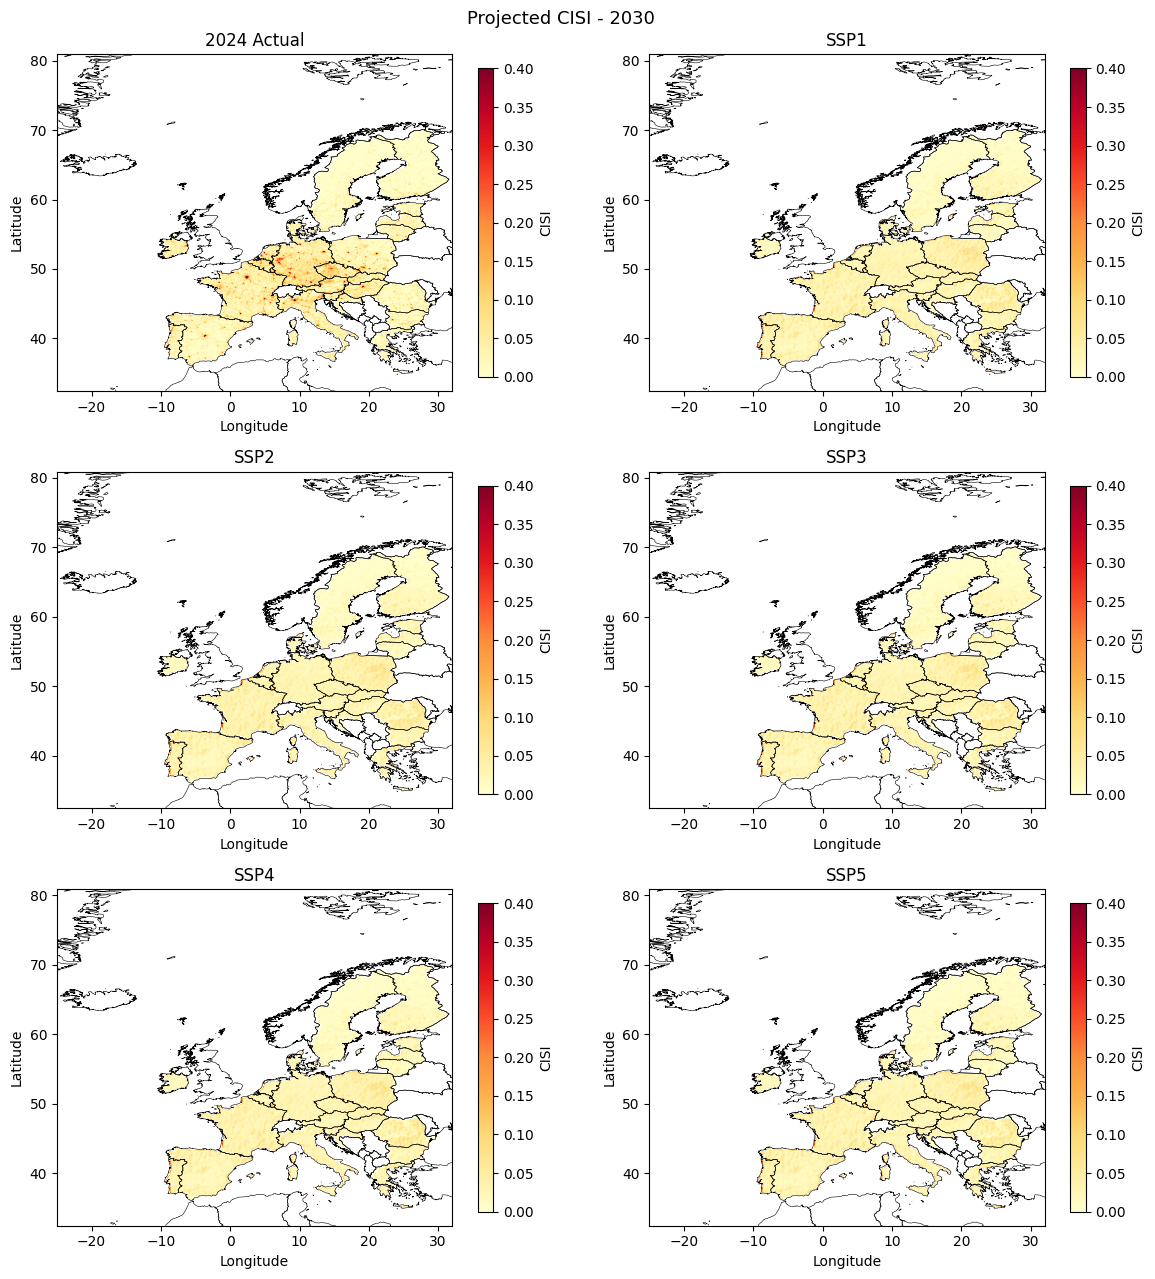

Saved projections_output/projections_2050.png


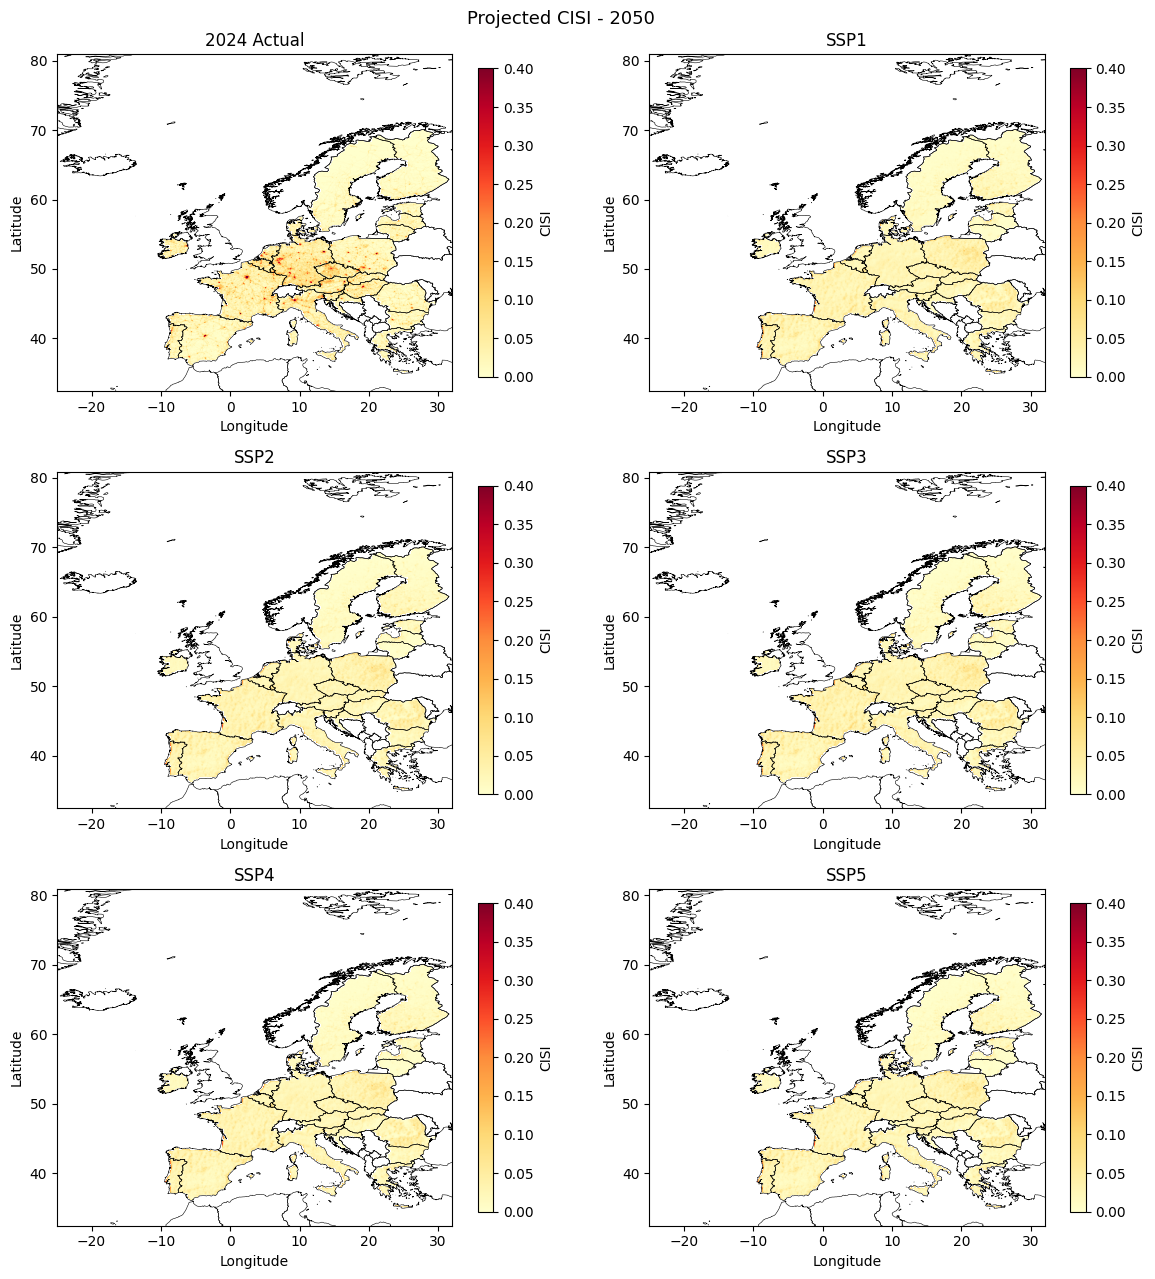

Saved projections_output/projections_2100.png


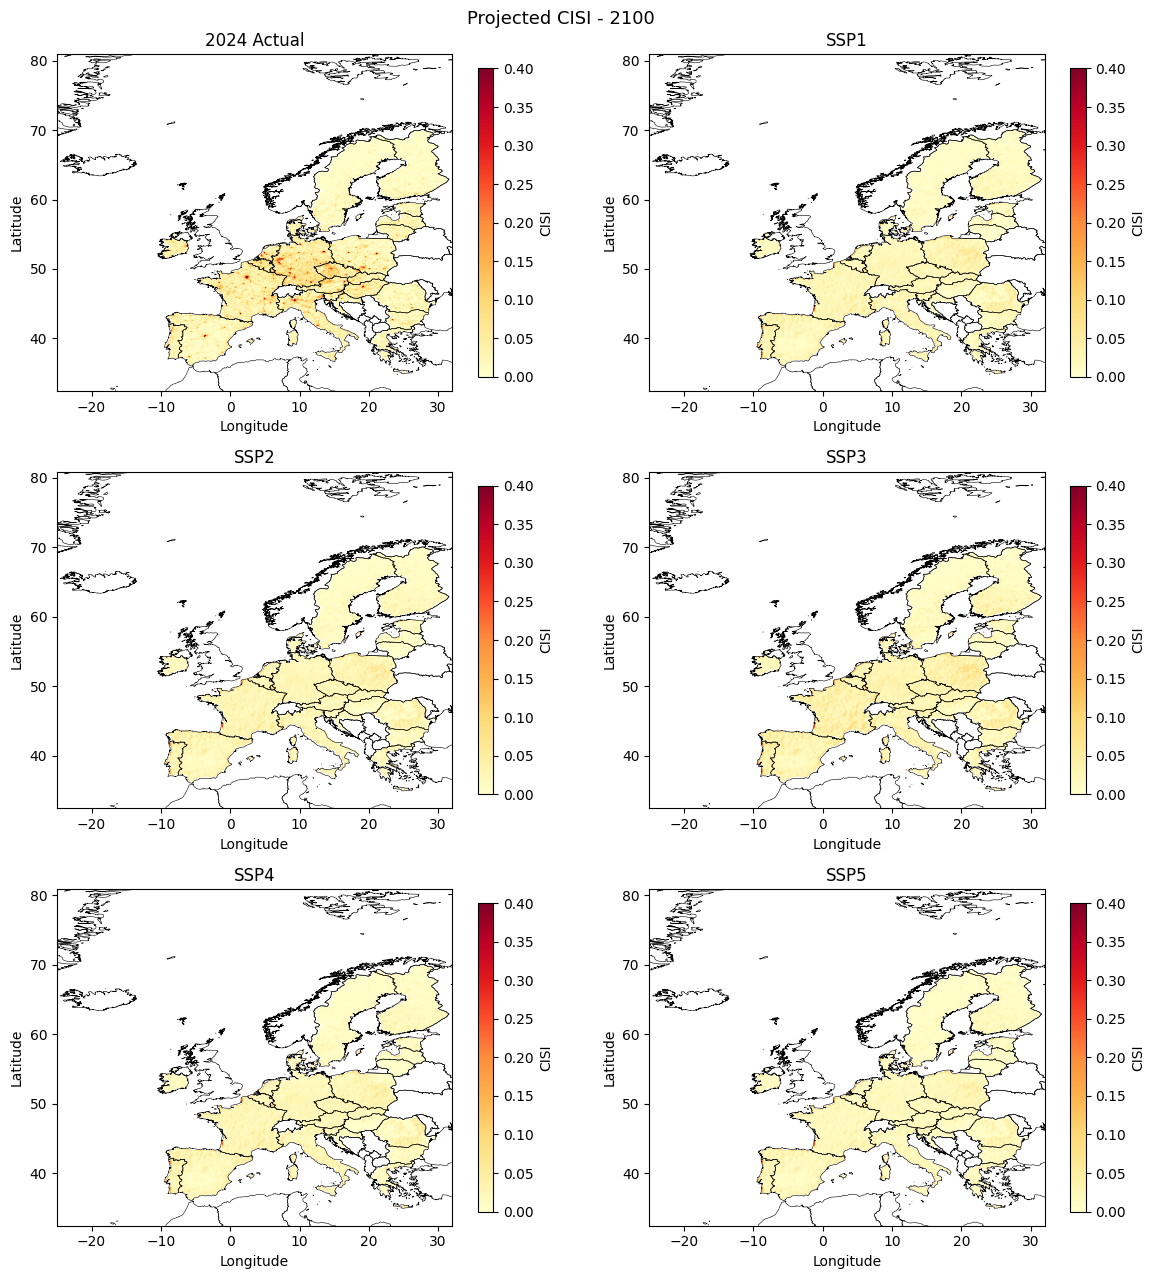

In [88]:
world = gpd.read_file(SHP_PATH)

SSPS  = [s for s in SCENARIOS if results.get(s)]
YEARS = [2030, 2050, 2100]

with rasterio.open(REFERENCE_RASTER) as ref:
    bounds    = ref.bounds
    cisi_2024 = ref.read(1).astype(np.float32)

cisi_2024_masked = np.where(VALID_MASK, cisi_2024, np.nan)
ext = [bounds.left, bounds.right, bounds.bottom, bounds.top]

for year in YEARS:
    ssps_with_data = [s for s in SSPS if year in results.get(s, {})]
    panels = [('2024 Actual', cisi_2024_masked)] + [(ssp, results[ssp][year]) for ssp in ssps_with_data]

    fig, axes = plt.subplots(3, 2, figsize=(12, 13))
    fig.suptitle(f'Projected CISI - {year}', fontsize=13)

    for ax, (title, data) in zip(axes.flat, panels):
        im = ax.imshow(data, cmap='YlOrRd', vmin=0, vmax=0.4,
                       extent=ext, origin='upper', aspect='auto')
        world.boundary.plot(ax=ax, linewidth=0.4, color='black')
        ax.set_xlim(bounds.left, bounds.right)
        ax.set_ylim(bounds.bottom, bounds.top)
        ax.set_title(title)
        ax.set_xlabel('Longitude'); ax.set_ylabel('Latitude')
        plt.colorbar(im, ax=ax, label='CISI', fraction=0.03)

    plt.tight_layout()
    out_fig = f'{FIGURES_DIR}/projections_{year}.png'
    plt.savefig(out_fig, dpi=150, bbox_inches='tight')
    print(f'Saved {out_fig}')
    plt.show()

## Summary statistics per SSP and year

In [89]:
print('SSP'.ljust(6) + 'Year'.rjust(6) + 'Mean'.rjust(8) + 'Std'.rjust(8)
      + 'Max'.rjust(8) + 'High>0.15(%)'.rjust(14))
print('-' * 50)
for ssp in SSPS:
    for year in YEARS:
        if year not in results.get(ssp, {}):
            continue
        vals = results[ssp][year][VALID_MASK]
        high = (vals > 0.15).mean() * 100
        print(ssp.ljust(6) + str(year).rjust(6)
              + str(round(float(vals.mean()), 4)).rjust(8)
              + str(round(float(vals.std()),  4)).rjust(8)
              + str(round(float(vals.max()),  4)).rjust(8)
              + (str(round(high, 1)) + '%').rjust(14))


SSP     Year    Mean     Std     Max  High>0.15(%)
--------------------------------------------------
SSP1    2030  0.0296   0.025  0.3223          0.6%
SSP1    2050   0.027  0.0244  0.3244          0.6%
SSP1    2100  0.0218  0.0227  0.3186          0.5%
SSP2    2030  0.0294  0.0249  0.3213          0.6%
SSP2    2050  0.0268  0.0243  0.3217          0.6%
SSP2    2100  0.0224   0.023  0.3217          0.5%
SSP3    2030  0.0295  0.0249  0.3219          0.6%
SSP3    2050  0.0282  0.0247  0.3228          0.6%
SSP3    2100  0.0286  0.0253  0.3229          0.6%
SSP4    2030  0.0293  0.0249  0.3213          0.6%
SSP4    2050  0.0264  0.0242  0.3218          0.6%
SSP4    2100  0.0207  0.0222  0.3169          0.5%
SSP5    2030  0.0288  0.0248  0.3219          0.6%
SSP5    2050  0.0251  0.0238  0.3227          0.6%
SSP5    2100   0.018  0.0213  0.3206          0.5%


In [90]:
import pandas as pd

with rasterio.open(REFERENCE_RASTER) as src:
    cisi_2024_full = src.read(1).astype(np.float32)

def compute_stats(arr, mask):
    vals      = arr[mask]
    vals      = vals[~np.isnan(vals)]
    city_mask = vals > 0.15
    return {
        'mean':       float(vals.mean()),
        'std':        float(vals.std()),
        'max':        float(vals.max()),
        'pct_city':   float(city_mask.mean() * 100),
        'city_mean':  float(vals[city_mask].mean()) if city_mask.sum() > 0 else float('nan'),
    }

rows = []

# 2024 baseline
s = compute_stats(cisi_2024_full, VALID_MASK)
rows.append({'Source': '2024 Actual', 'Mean': s['mean'], 'Std': s['std'],
             'Max': s['max'], '% >0.15': s['pct_city'], 'City Mean': s['city_mean']})

# 2030 projections per SSP
for ssp in SSPS:
    if 2030 not in results.get(ssp, {}):
        continue
    s = compute_stats(results[ssp][2030], VALID_MASK)
    rows.append({'Source': f'{ssp} 2030', 'Mean': s['mean'], 'Std': s['std'],
                 'Max': s['max'], '% >0.15': s['pct_city'], 'City Mean': s['city_mean']})

df_cmp = pd.DataFrame(rows).set_index('Source')
print(df_cmp.to_string(float_format=lambda x: f'{x:.4f}'))

              Mean    Std    Max  % >0.15  City Mean
Source                                              
2024 Actual 0.0339 0.0425 0.8959   2.1619     0.2195
SSP1 2030   0.0296 0.0250 0.3223   0.6031     0.2066
SSP2 2030   0.0294 0.0249 0.3213   0.6105     0.2064
SSP3 2030   0.0295 0.0249 0.3219   0.6049     0.2073
SSP4 2030   0.0293 0.0249 0.3213   0.6086     0.2066
SSP5 2030   0.0288 0.0248 0.3219   0.6142     0.2058


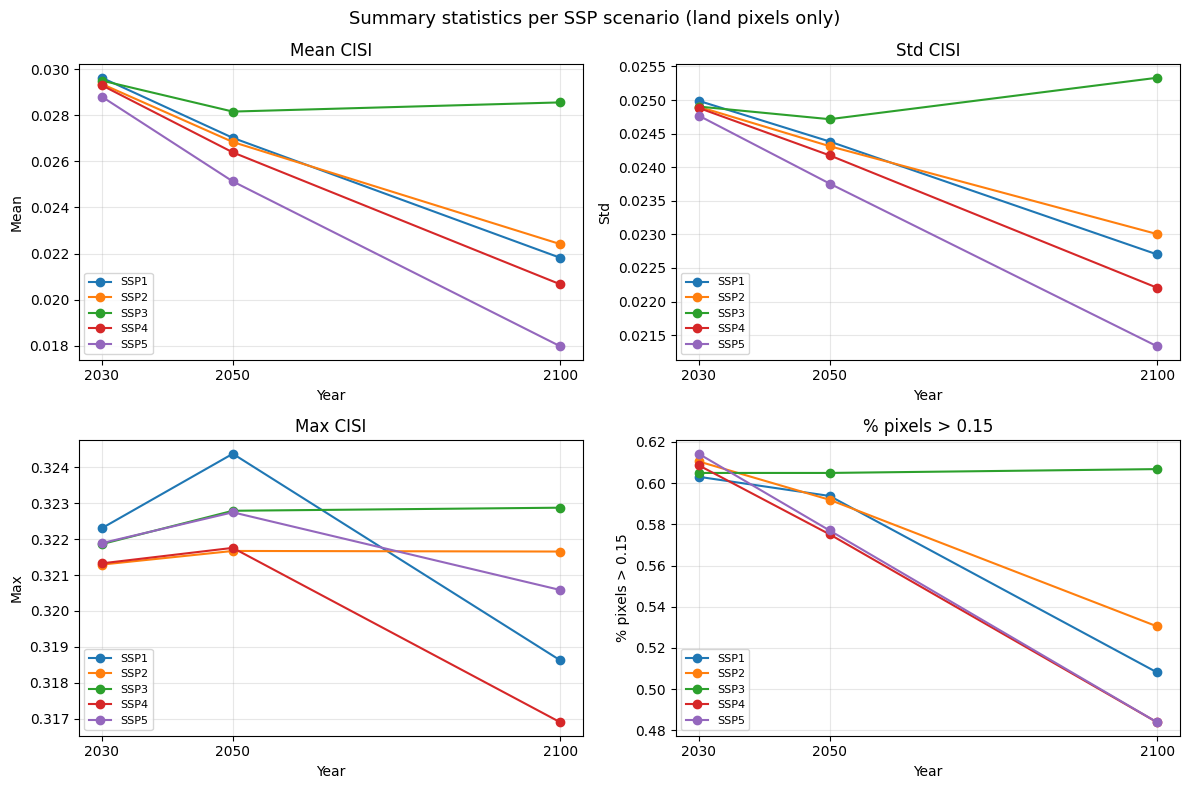

In [91]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle('Summary statistics per SSP scenario (land pixels only)', fontsize=13)

stats = {ssp: {m: [] for m in ['mean', 'std', 'max', 'high']} for ssp in SSPS}
for ssp in SSPS:
    for year in YEARS:
        if year not in results.get(ssp, {}):
            for m in stats[ssp]: stats[ssp][m].append(np.nan)
            continue
        vals = results[ssp][year][VALID_MASK]
        stats[ssp]['mean'].append(float(vals.mean()))
        stats[ssp]['std'].append(float(vals.std()))
        stats[ssp]['max'].append(float(vals.max()))
        stats[ssp]['high'].append(float((vals > 0.15).mean() * 100))

titles  = ['Mean CISI', 'Std CISI', 'Max CISI', '% pixels > 0.15']
keys    = ['mean', 'std', 'max', 'high']
ylabels = ['Mean', 'Std', 'Max', '% pixels > 0.15']

for ax, key, title, ylabel in zip(axes.flat, keys, titles, ylabels):
    for ssp in SSPS:
        ax.plot(YEARS, stats[ssp][key], marker='o', label=ssp)
    ax.set_title(title)
    ax.set_xlabel('Year'); ax.set_ylabel(ylabel)
    ax.set_xticks(YEARS); ax.legend(fontsize=8); ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/summary_stats.png', dpi=150, bbox_inches='tight')
plt.show()

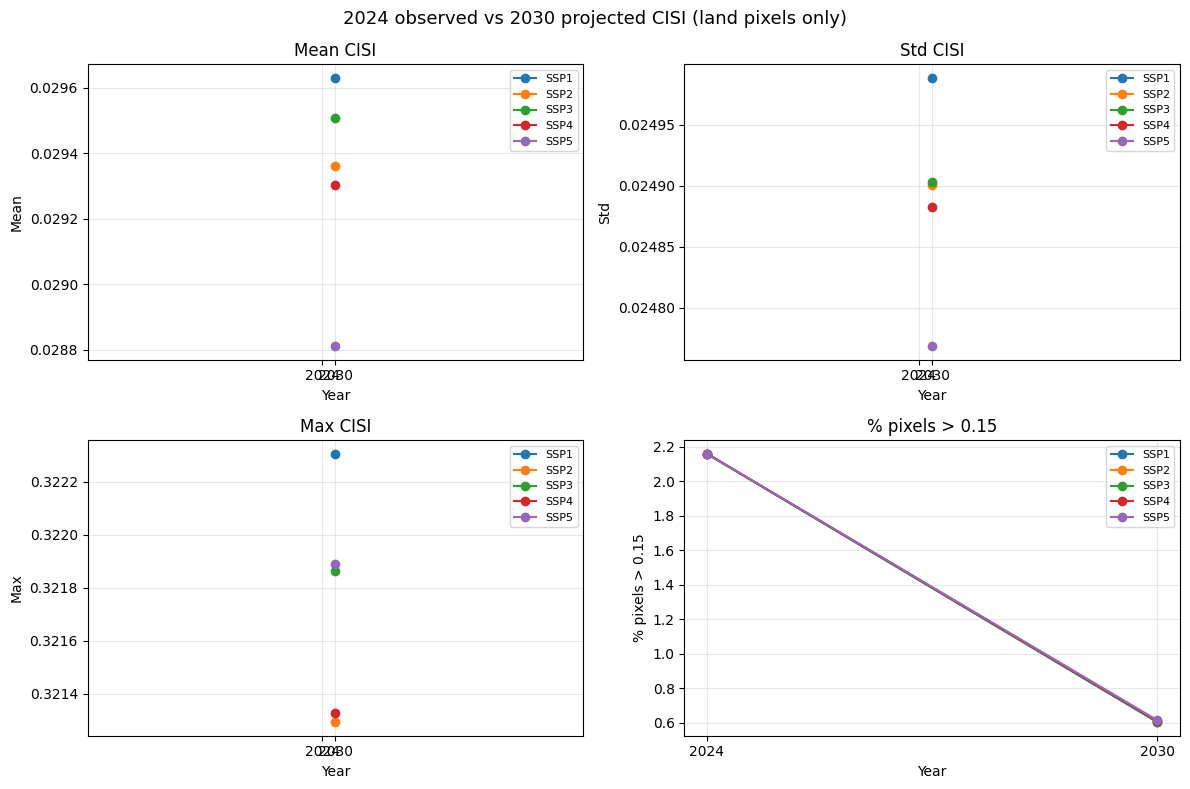

In [92]:
with rasterio.open(REFERENCE_RASTER) as src:
    cisi_2024 = src.read(1).astype(np.float32)

valid_2024 = cisi_2024[VALID_MASK]
stats_2024 = {
    'mean': float(valid_2024.mean()),
    'std':  float(valid_2024.std()),
    'max':  float(valid_2024.max()),
    'high': float((valid_2024 > 0.15).mean() * 100),
}

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle('2024 observed vs 2030 projected CISI (land pixels only)', fontsize=13)

keys    = ['mean', 'std', 'max', 'high']
titles  = ['Mean CISI', 'Std CISI', 'Max CISI', '% pixels > 0.15']
ylabels = ['Mean', 'Std', 'Max', '% pixels > 0.15']

for ax, key, title, ylabel in zip(axes.flat, keys, titles, ylabels):
    y_2024 = stats_2024[key]
    for ssp in SSPS:
        if 2030 not in results.get(ssp, {}):
            continue
        y_2030 = stats[ssp][key][YEARS.index(2030)]
        ax.plot([2024, 2030], [y_2024, y_2030], marker='o', label=ssp)
    ax.set_title(title)
    ax.set_xlabel('Year'); ax.set_ylabel(ylabel)
    ax.set_xticks([2024, 2030]); ax.legend(fontsize=8); ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/stats_2024_2030.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
COLORS = {'SSP1': '#4daf4a', 'SSP2': '#377eb8', 'SSP3': '#ff7f00',
          'SSP4': '#984ea3', 'SSP5': '#e41a1c'}

baseline_mean = float(np.nanmean(cisi_2024[VALID_MASK]))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Projected CISI vs 2024 baseline', fontsize=13)

ax1, ax2 = axes
for ssp in SSPS:
    means = [float(np.nanmean(results[ssp][y][VALID_MASK])) for y in YEARS if y in results.get(ssp, {})]
    yrs   = [y for y in YEARS if y in results.get(ssp, {})]
    ax1.plot(yrs, means, marker='o', color=COLORS[ssp], linewidth=2, label=ssp)
ax1.axhline(baseline_mean, color='black', linestyle='--', linewidth=1.5, label='2024 observed')
ax1.set_title('Mean CISI per SSP over time')
ax1.set_xlabel('Year'); ax1.set_xticks(YEARS)
ax1.set_ylabel('Mean CISI'); ax1.legend(fontsize=9); ax1.grid(True, alpha=0.3)

spread_means = []
for year in YEARS:
    if year in results.get('SSP5', {}) and year in results.get('SSP1', {}):
        diff = results['SSP5'][year][VALID_MASK] - results['SSP1'][year][VALID_MASK]
        spread_means.append(float(np.nanmean(diff)))
    else:
        spread_means.append(np.nan)
ax2.bar([str(y) for y in YEARS], spread_means, color='#e41a1c', alpha=0.8)
ax2.axhline(0, color='black', linewidth=1)
ax2.set_title('SSP5 vs SSP1 scenario spread')
ax2.set_xlabel('Year'); ax2.set_ylabel('Mean(SSP5 - SSP1)'); ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/summary_baseline_and_spread.png', dpi=150, bbox_inches='tight')
plt.show()
print('2024 baseline mean (land):', round(baseline_mean, 4))
for ssp in SSPS:
    means = [round(float(np.nanmean(results[ssp][y][VALID_MASK])), 4) for y in YEARS if y in results.get(ssp, {})]
    print(ssp + ':', means)

## Per-year overview — 2×3 grid (2024 actual + SSP1–5)

Saved projections_output/full_projection_overview_2030.png


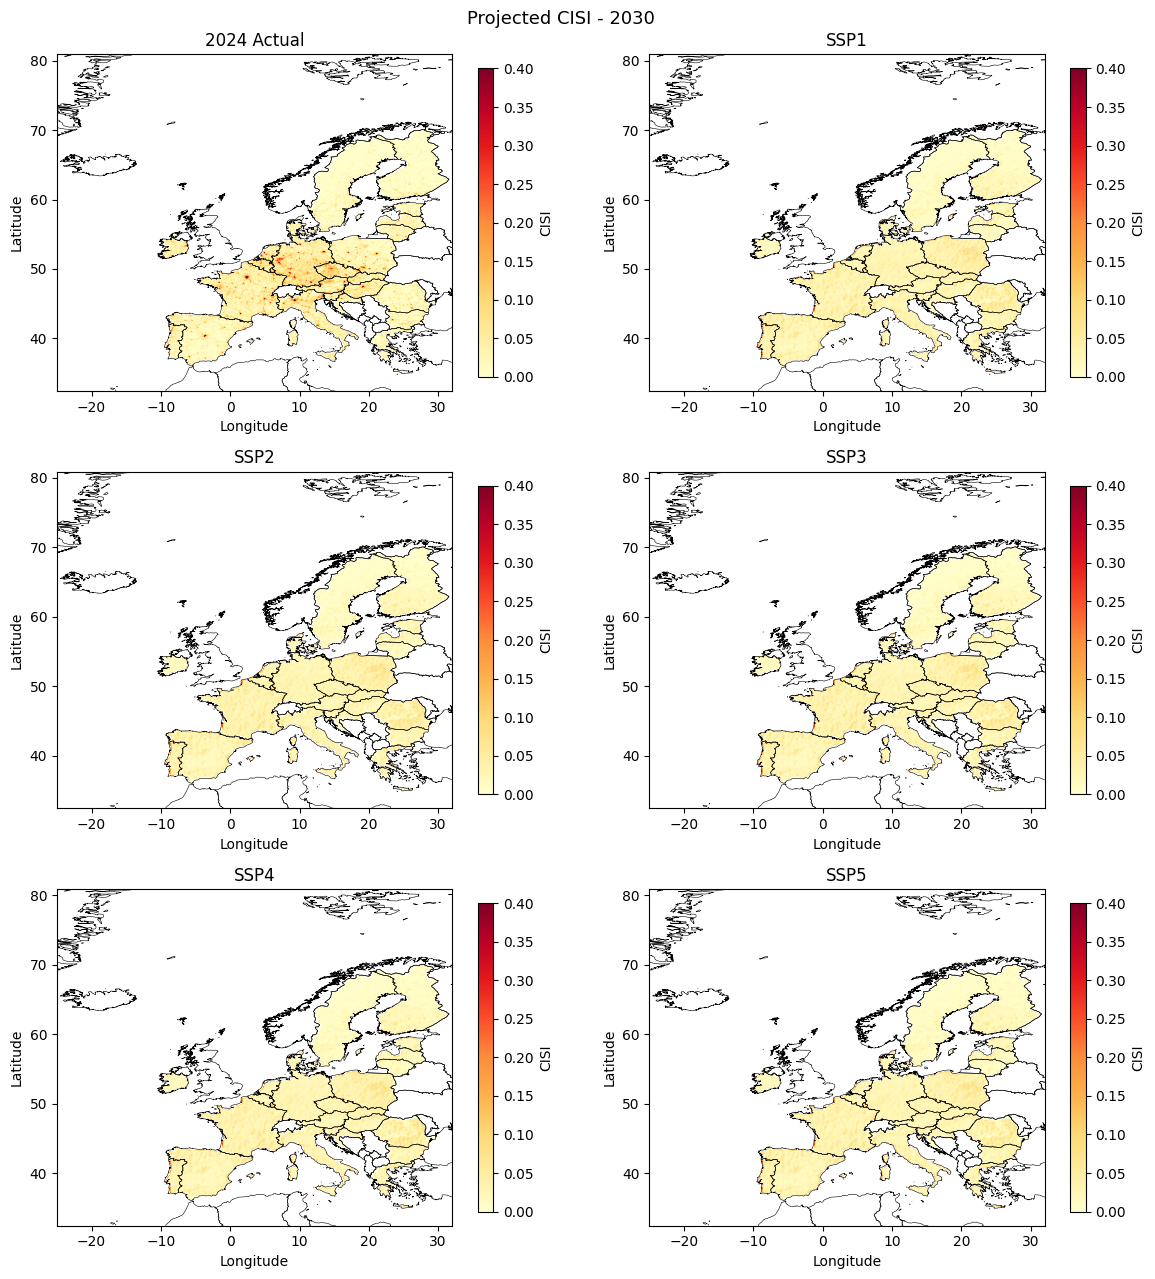

Saved projections_output/full_projection_overview_2050.png


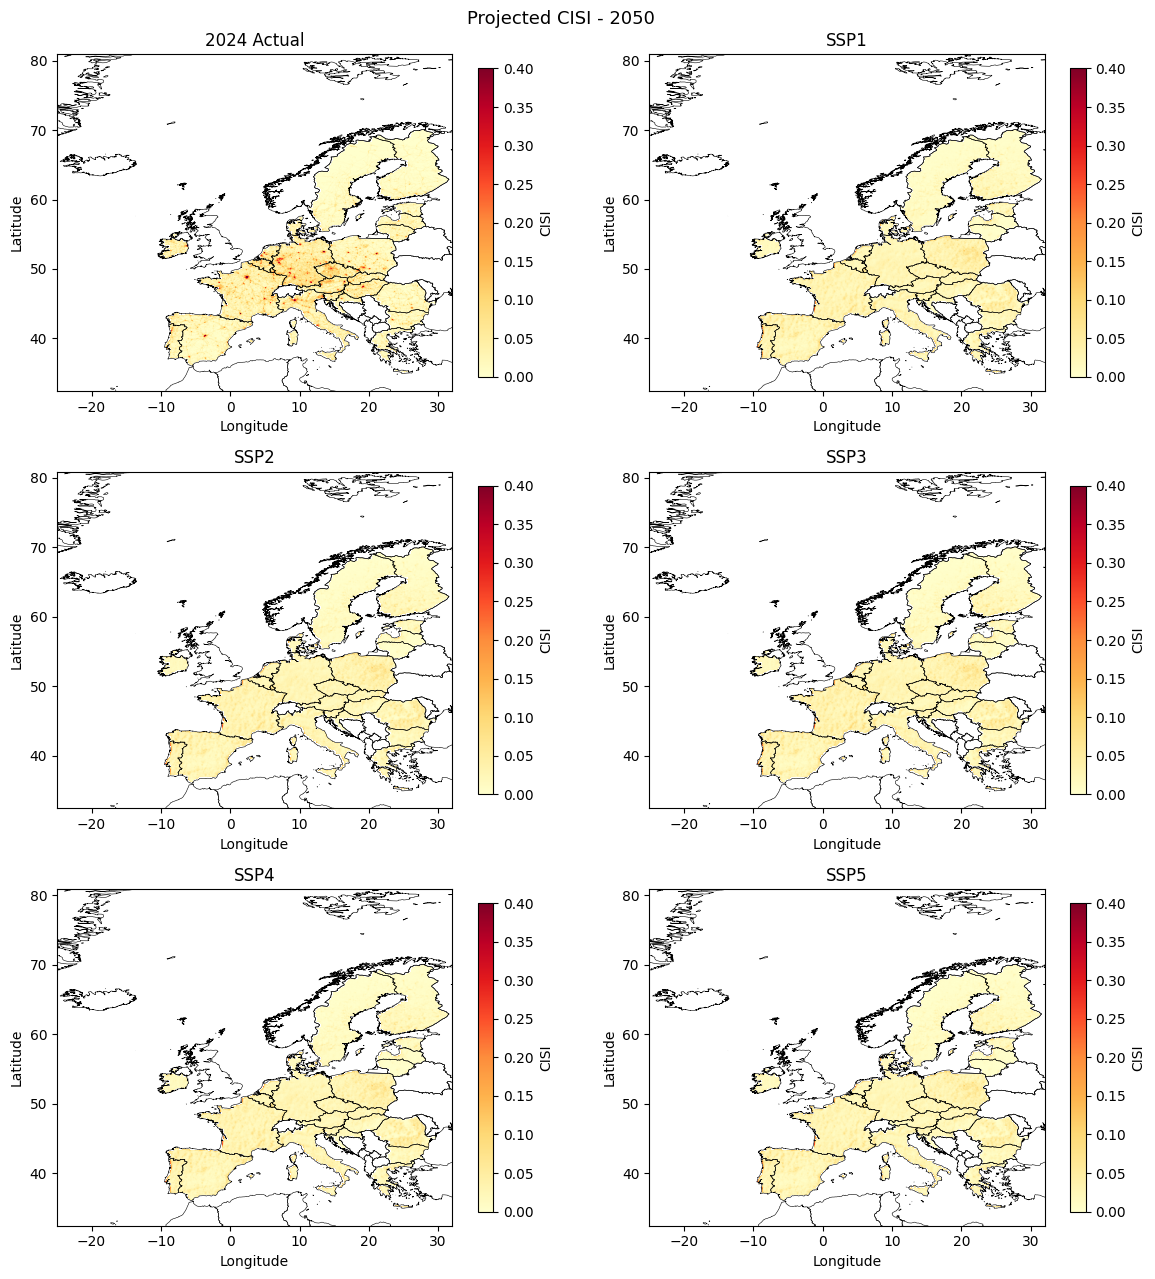

Saved projections_output/full_projection_overview_2100.png


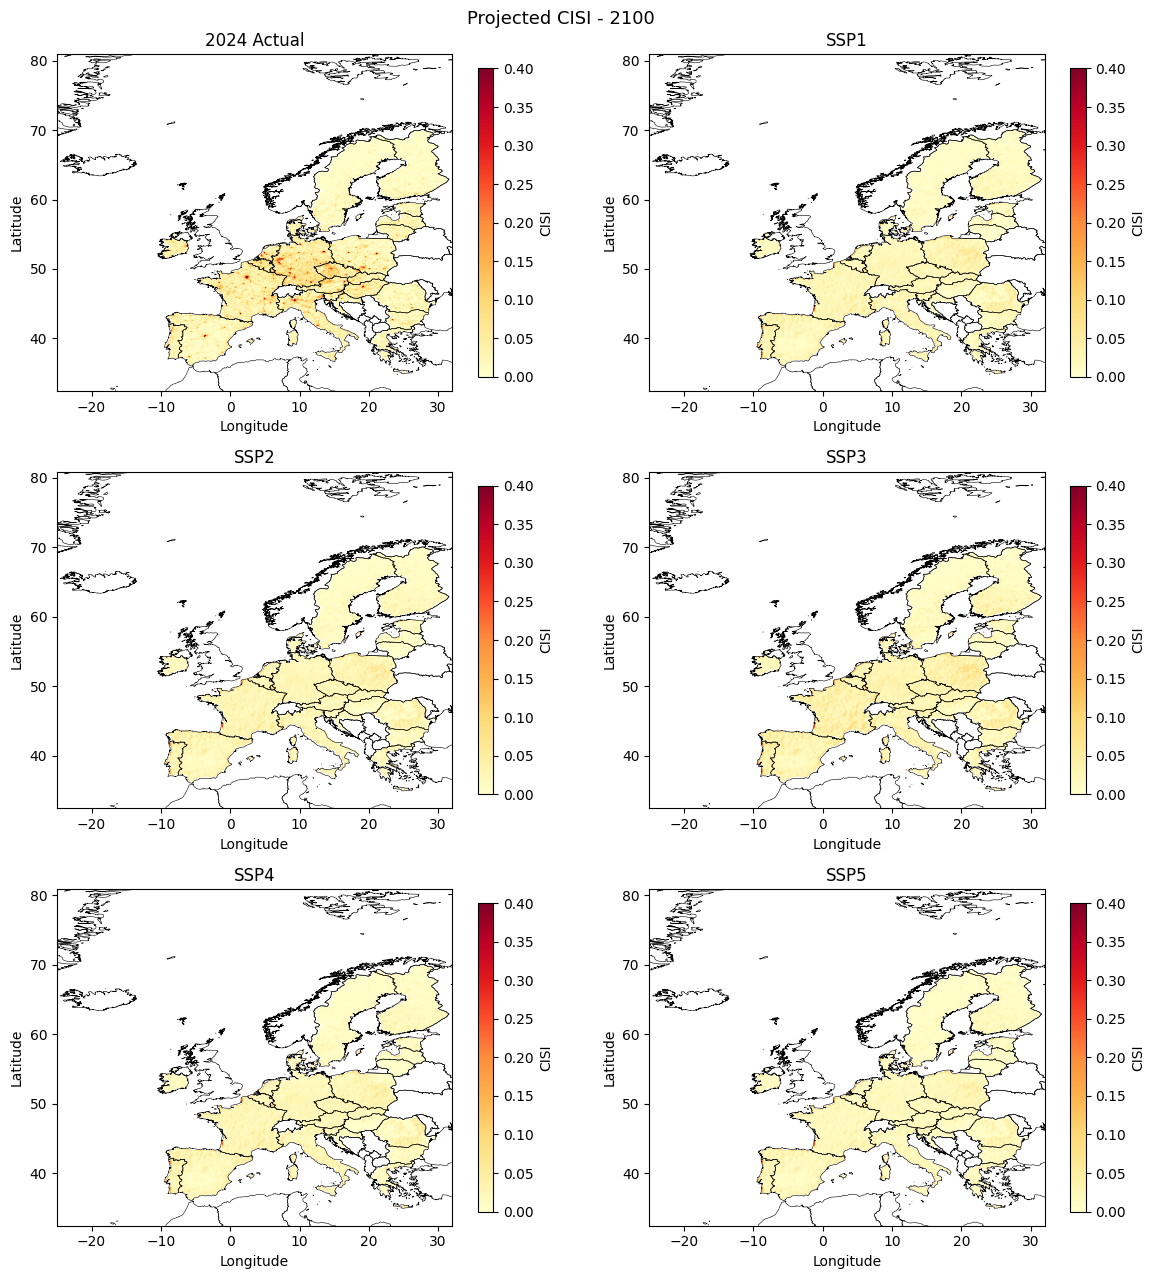

In [94]:
with rasterio.open(REFERENCE_RASTER) as src:
    cisi_2024 = src.read(1).astype(np.float32)
    bounds    = src.bounds

cisi_2024_masked = np.where(VALID_MASK, cisi_2024, np.nan)
ext = [bounds.left, bounds.right, bounds.bottom, bounds.top]

for year in YEARS:
    panels = [
        ('2024 Actual', cisi_2024_masked),
        ('SSP1',        results['SSP1'][year]),
        ('SSP2',        results['SSP2'][year]),
        ('SSP3',        results['SSP3'][year]),
        ('SSP4',        results['SSP4'][year]),
        ('SSP5',        results['SSP5'][year]),
    ]

    fig, axes = plt.subplots(3, 2, figsize=(12, 13))
    fig.suptitle(f'Projected CISI - {year}', fontsize=13)

    for ax, (title, data) in zip(axes.flat, panels):
        im = ax.imshow(data, cmap='YlOrRd', vmin=0, vmax=0.4,
                       extent=ext, origin='upper', aspect='auto')
        world.boundary.plot(ax=ax, linewidth=0.4, color='black')
        ax.set_xlim(bounds.left, bounds.right)
        ax.set_ylim(bounds.bottom, bounds.top)
        ax.set_title(title)
        ax.set_xlabel('Longitude'); ax.set_ylabel('Latitude')
        plt.colorbar(im, ax=ax, label='CISI', fraction=0.03)

    plt.tight_layout()
    out_fig = f'{FIGURES_DIR}/full_projection_overview_{year}.png'
    plt.savefig(out_fig, dpi=150, bbox_inches='tight')
    print(f'Saved {out_fig}')
    plt.show()

Saved projections_output/full_distribution_overview_2030.png


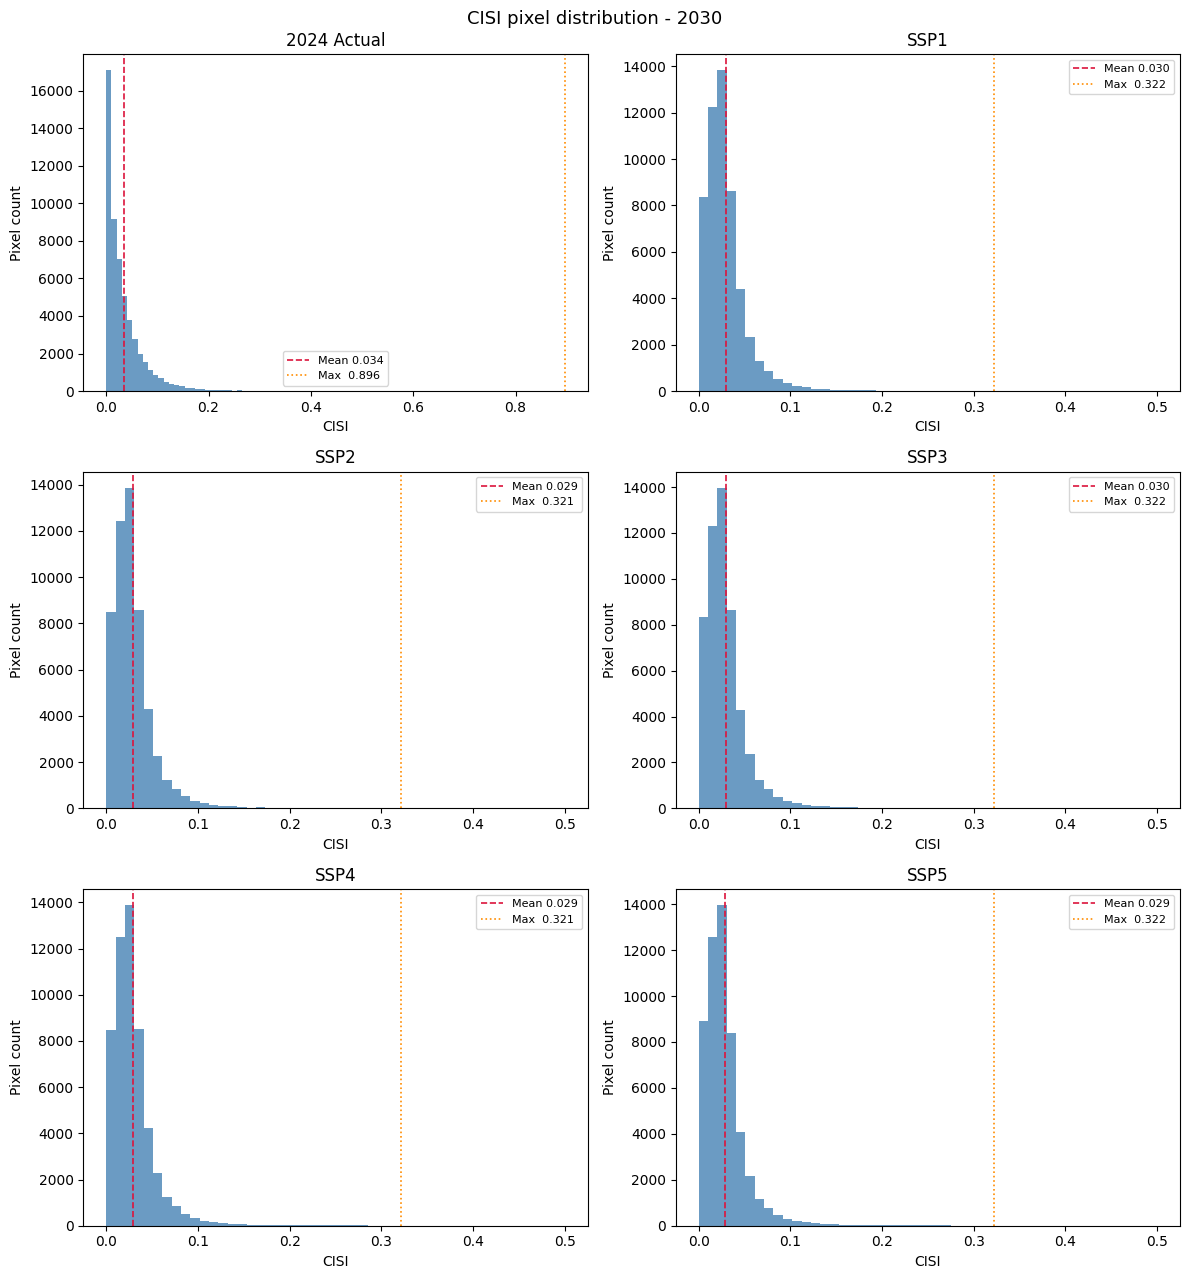

Saved projections_output/full_distribution_overview_2050.png


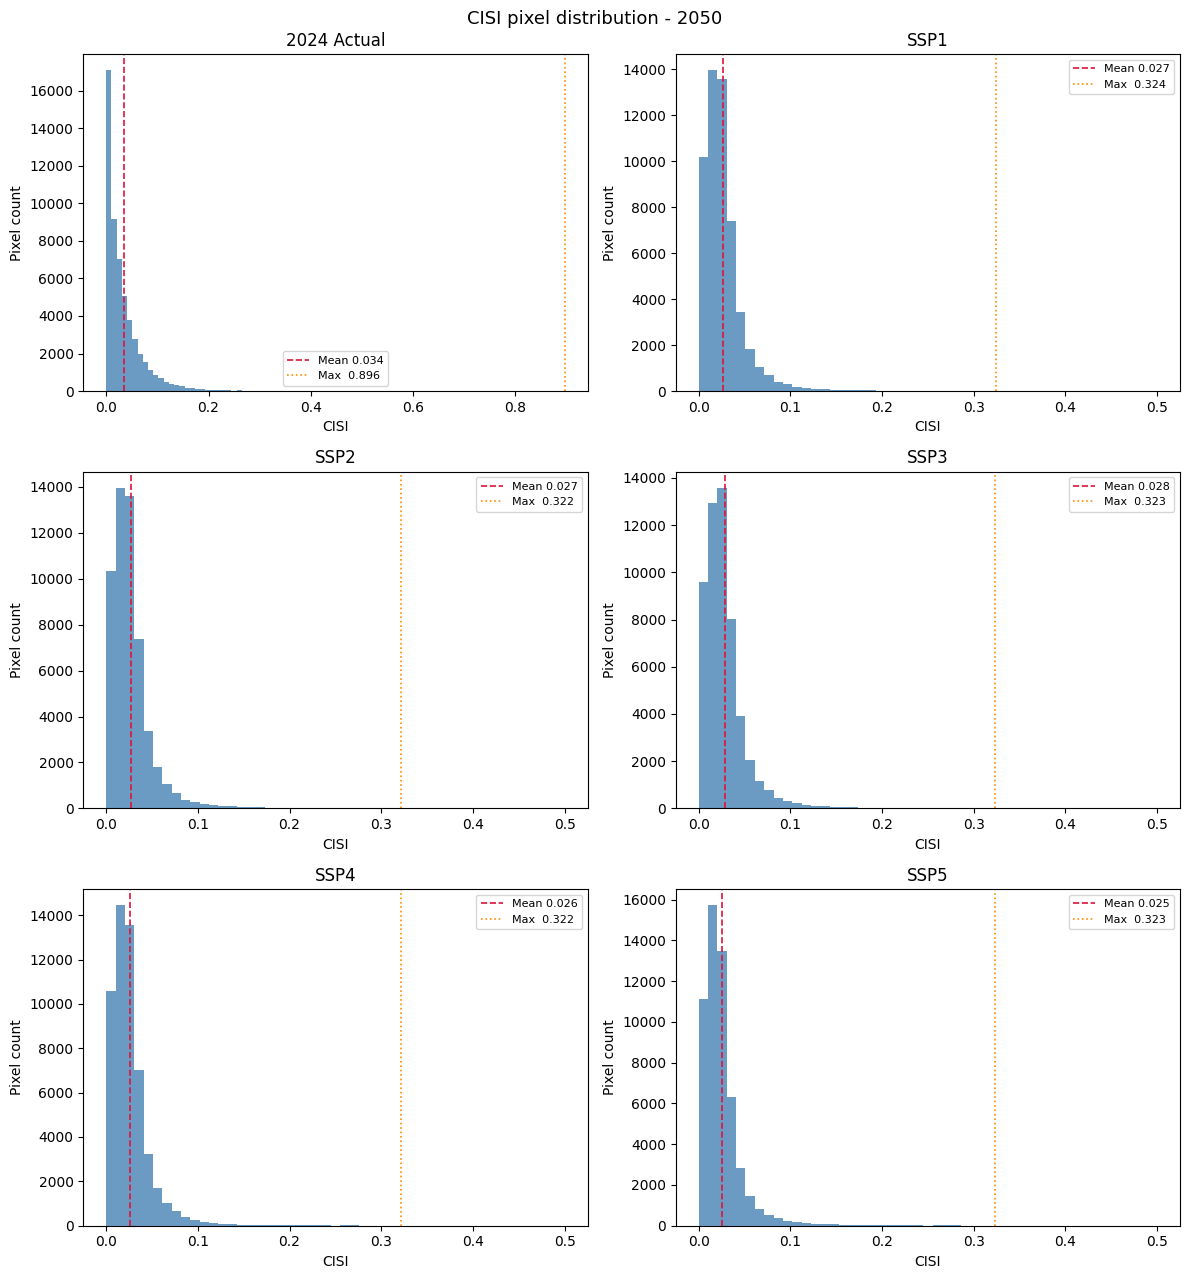

Saved projections_output/full_distribution_overview_2100.png


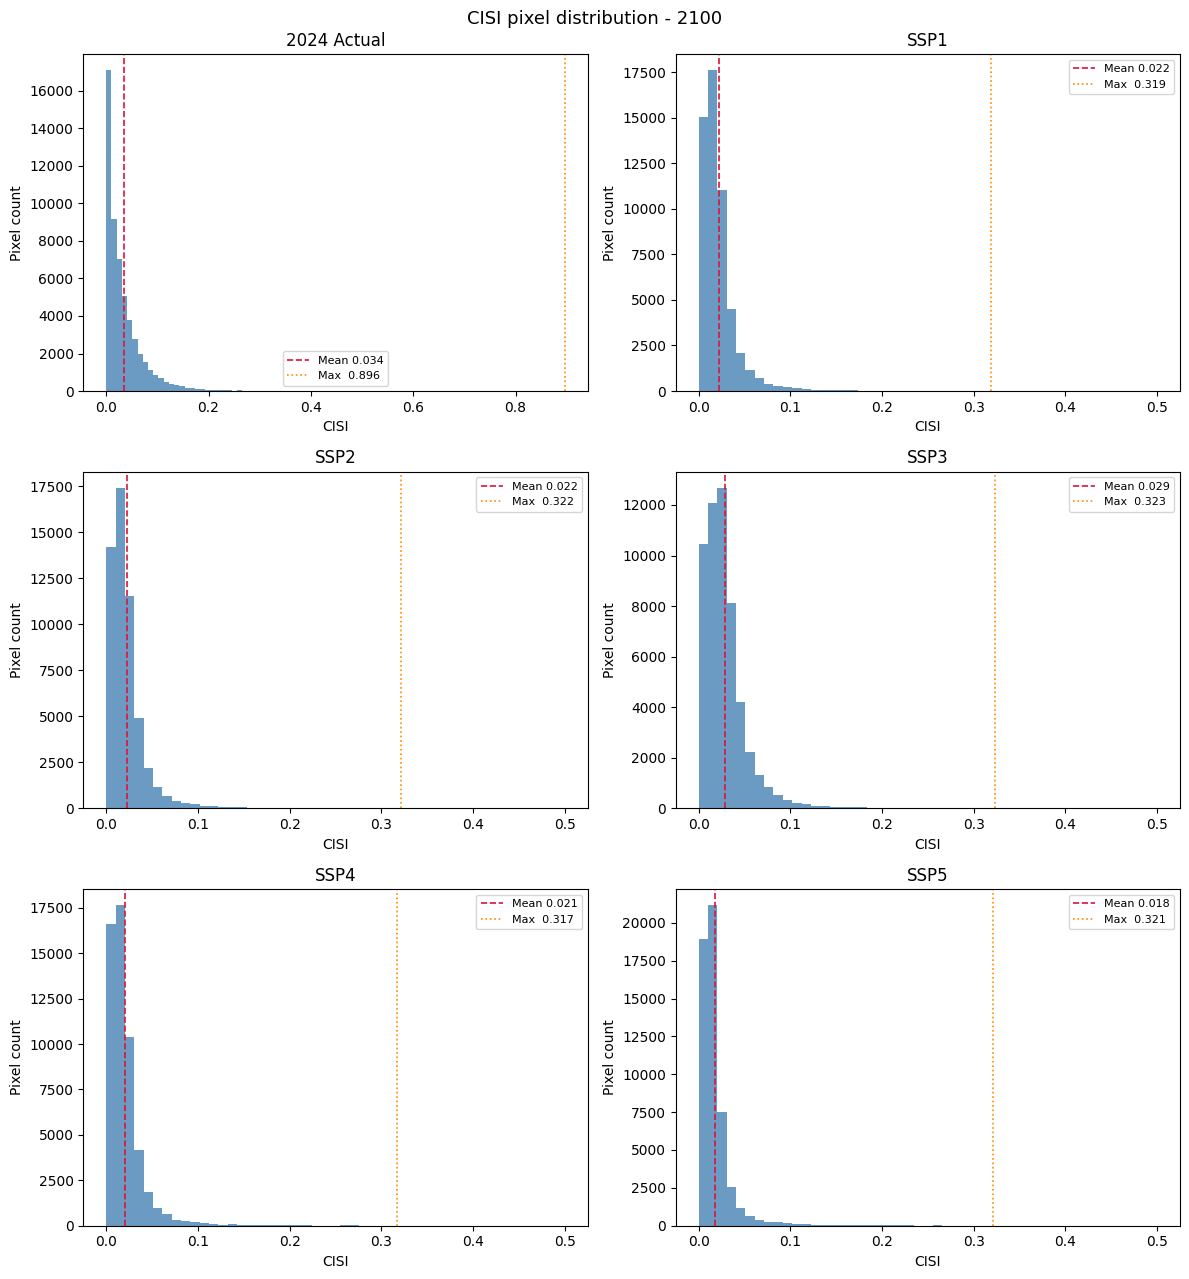

In [95]:
bins = np.linspace(0, 0.5, 50)

for year in YEARS:
    panels = [
        ('2024 Actual', cisi_2024_masked),
        ('SSP1',        results['SSP1'][year]),
        ('SSP2',        results['SSP2'][year]),
        ('SSP3',        results['SSP3'][year]),
        ('SSP4',        results['SSP4'][year]),
        ('SSP5',        results['SSP5'][year]),
    ]

    fig, axes = plt.subplots(3, 2, figsize=(12, 13))
    fig.suptitle(f'CISI pixel distribution - {year}', fontsize=13)

    for ax, (title, data) in zip(axes.flat, panels):
        vals = data[~np.isnan(data)]
        ax.hist(vals, bins=bins, color='steelblue', alpha=0.8)
        ax.axvline(vals.mean(), color='crimson',    linestyle='--', linewidth=1.2, label=f'Mean {vals.mean():.3f}')
        ax.axvline(vals.max(),  color='darkorange', linestyle=':',  linewidth=1.2, label=f'Max  {vals.max():.3f}')
        ax.set_title(title)
        ax.set_xlabel('CISI'); ax.set_ylabel('Pixel count')
        ax.legend(fontsize=8)

    plt.tight_layout()
    out_fig = f'{FIGURES_DIR}/full_distribution_overview_{year}.png'
    plt.savefig(out_fig, dpi=150, bbox_inches='tight')
    print(f'Saved {out_fig}')
    plt.show()

## SSP scenario difference analysis

Compares SSP scenarios against each other and over time. Shows: (1) summary stats table, (2) mean CISI over time per SSP, (3) spatial difference maps between SSP1 and SSP5 per year, (4) per-SSP spread across years.

 SSP  Year   Mean    Std    Max  pct>0.15
SSP1  2030 0.0296 0.0250 0.3223    0.6031
SSP1  2050 0.0270 0.0244 0.3244    0.5938
SSP1  2100 0.0218 0.0227 0.3186    0.5081
SSP2  2030 0.0294 0.0249 0.3213    0.6105
SSP2  2050 0.0268 0.0243 0.3217    0.5919
SSP2  2100 0.0224 0.0230 0.3217    0.5305
SSP3  2030 0.0295 0.0249 0.3219    0.6049
SSP3  2050 0.0282 0.0247 0.3228    0.6049
SSP3  2100 0.0286 0.0253 0.3229    0.6068
SSP4  2030 0.0293 0.0249 0.3213    0.6086
SSP4  2050 0.0264 0.0242 0.3218    0.5751
SSP4  2100 0.0207 0.0222 0.3169    0.4839
SSP5  2030 0.0288 0.0248 0.3219    0.6142
SSP5  2050 0.0251 0.0238 0.3227    0.5770
SSP5  2100 0.0180 0.0213 0.3206    0.4839



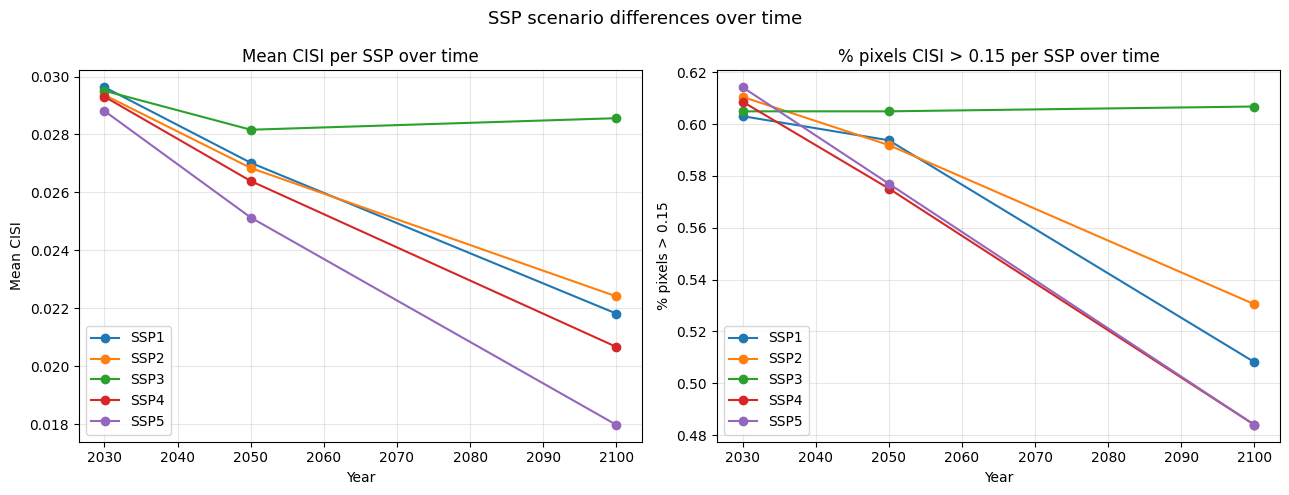

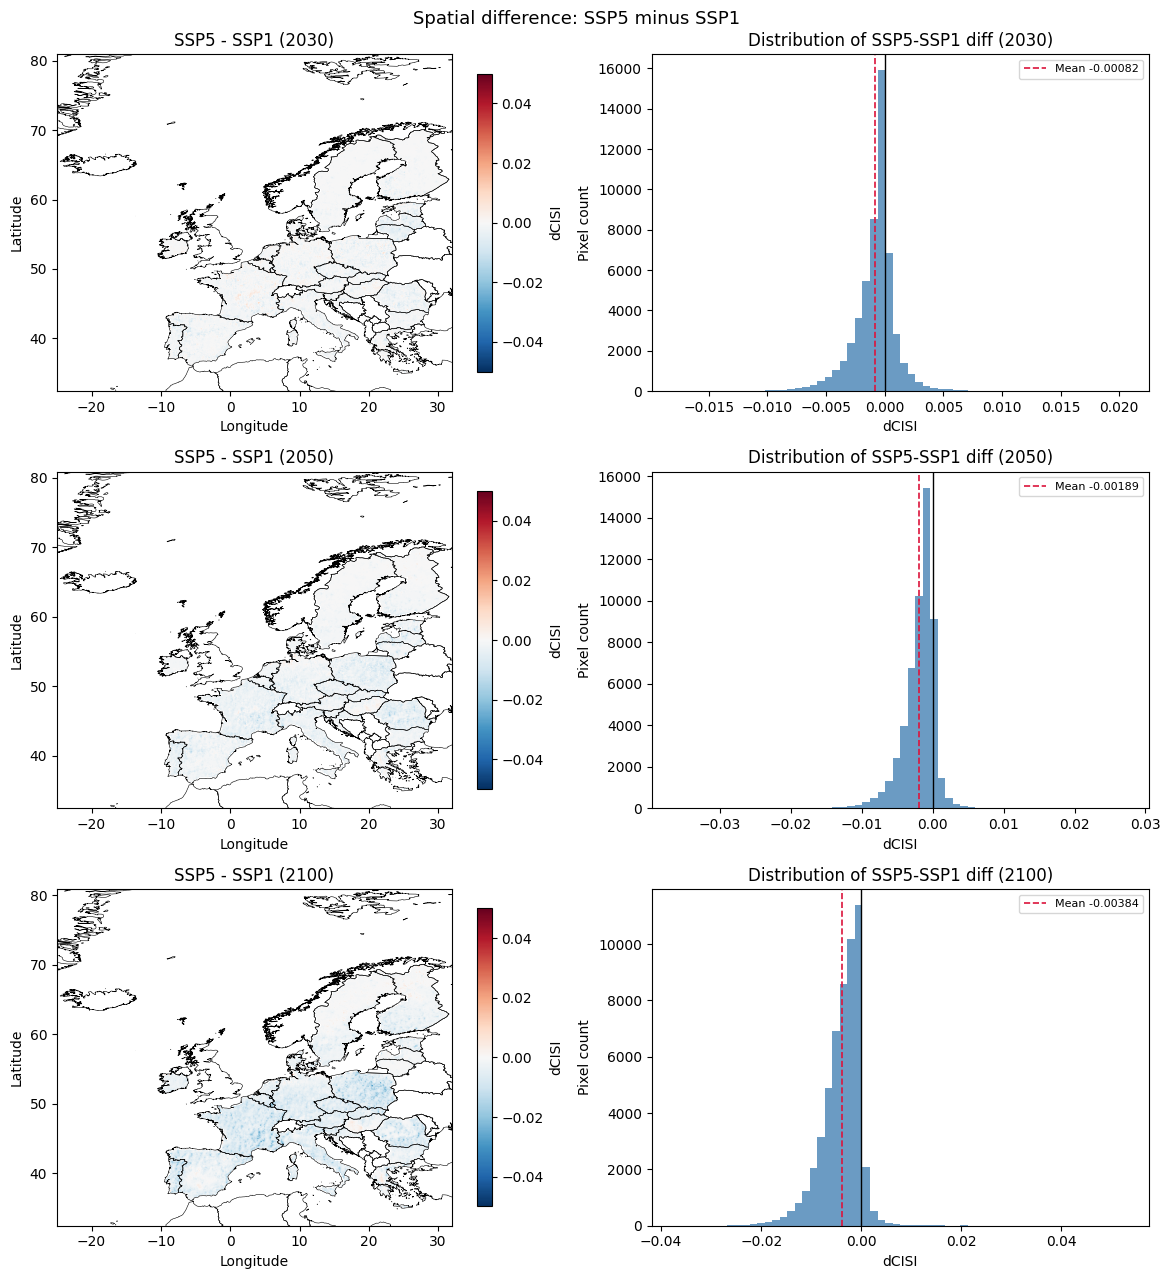

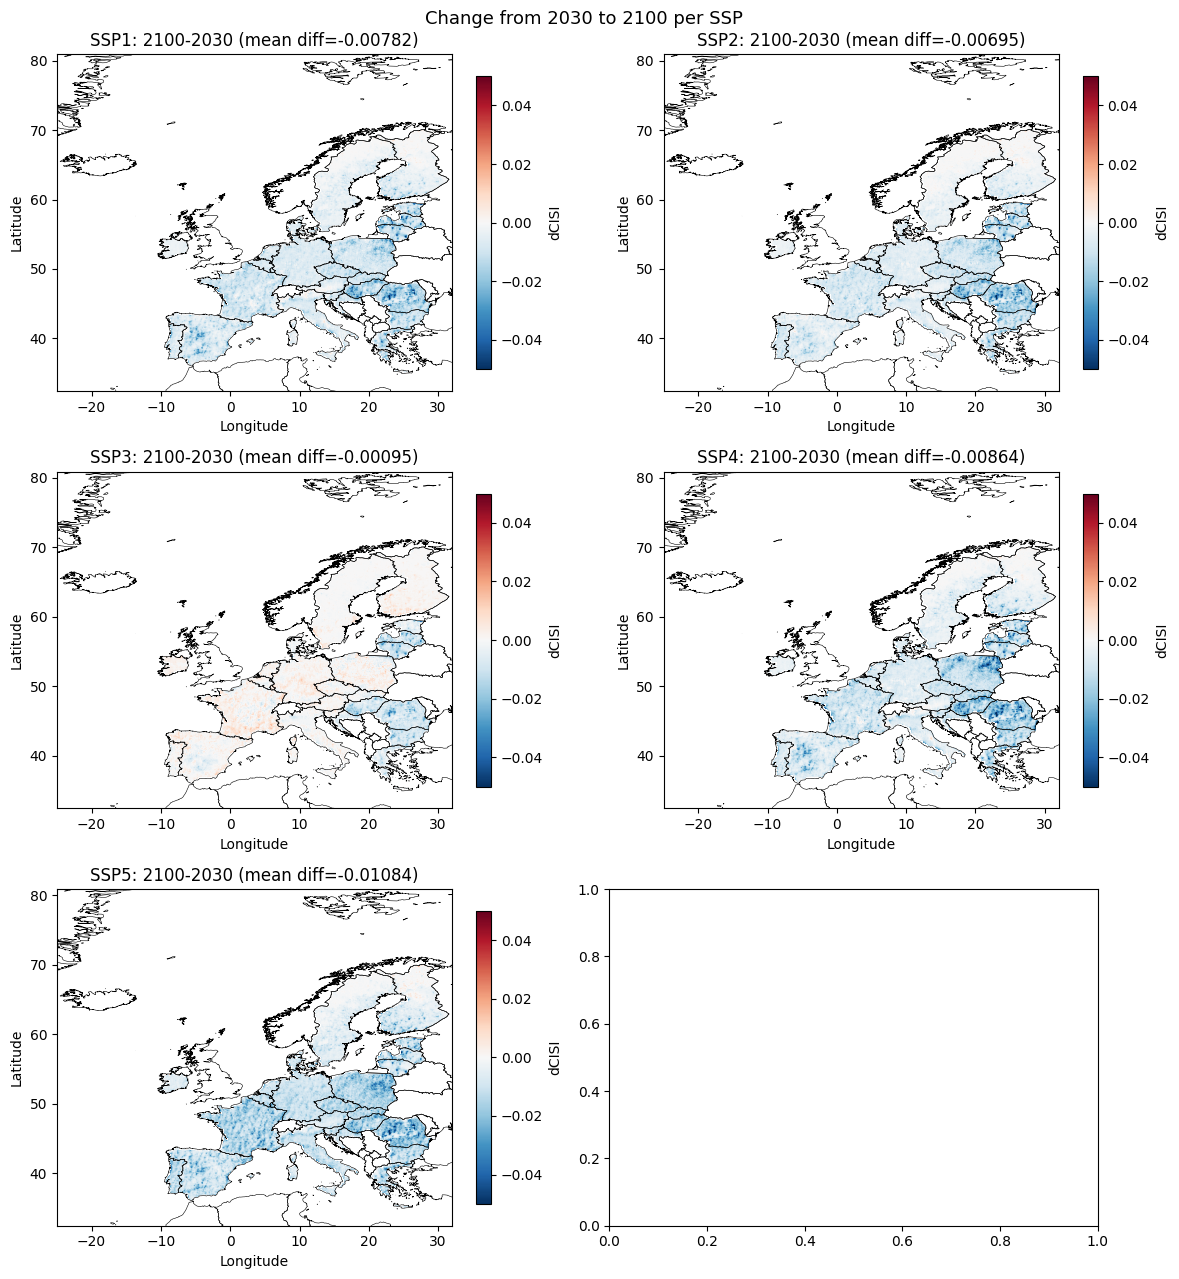

In [96]:
import pandas as pd

rows = []
for ssp in SSPS:
    for year in YEARS:
        vals = results[ssp][year][VALID_MASK]
        rows.append({'SSP': ssp, 'Year': year,
                     'Mean': vals.mean(), 'Std': vals.std(),
                     'Max': vals.max(), 'pct>0.15': (vals > 0.15).mean() * 100})
df = pd.DataFrame(rows)
print(df.to_string(index=False, float_format=lambda x: f'{x:.4f}'))
print()

colors = {'SSP1': '#1f77b4', 'SSP2': '#ff7f0e', 'SSP3': '#2ca02c',
          'SSP4': '#d62728', 'SSP5': '#9467bd'}

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('SSP scenario differences over time', fontsize=13)

ax = axes[0]
for ssp in SSPS:
    means = [df[(df.SSP==ssp) & (df.Year==y)]['Mean'].values[0] for y in YEARS]
    ax.plot(YEARS, means, marker='o', label=ssp, color=colors.get(ssp))
ax.set_title('Mean CISI per SSP over time')
ax.set_xlabel('Year'); ax.set_ylabel('Mean CISI')
ax.legend(); ax.grid(alpha=0.3)

ax = axes[1]
for ssp in SSPS:
    highs = [df[(df.SSP==ssp) & (df.Year==y)]['pct>0.15'].values[0] for y in YEARS]
    ax.plot(YEARS, highs, marker='o', label=ssp, color=colors.get(ssp))
ax.set_title('% pixels CISI > 0.15 per SSP over time')
ax.set_xlabel('Year'); ax.set_ylabel('% pixels > 0.15')
ax.legend(); ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/ssp_difference_over_time.png', dpi=150, bbox_inches='tight')
plt.show()

fig, axes = plt.subplots(3, 2, figsize=(12, 13))
fig.suptitle('Spatial difference: SSP5 minus SSP1', fontsize=13)

for row, year in enumerate(YEARS):
    diff = results['SSP5'][year] - results['SSP1'][year]

    ax = axes[row, 0]
    im = ax.imshow(diff, cmap='RdBu_r', vmin=-0.05, vmax=0.05,
                   extent=ext, origin='upper', aspect='auto')
    world.boundary.plot(ax=ax, linewidth=0.4, color='black')
    ax.set_xlim(bounds.left, bounds.right); ax.set_ylim(bounds.bottom, bounds.top)
    ax.set_title(f'SSP5 - SSP1 ({year})')
    ax.set_xlabel('Longitude'); ax.set_ylabel('Latitude')
    plt.colorbar(im, ax=ax, label='dCISI', fraction=0.03)

    ax = axes[row, 1]
    dvals = diff[~np.isnan(diff)]
    ax.hist(dvals, bins=60, color='steelblue', alpha=0.8)
    ax.axvline(0, color='black', linewidth=1)
    ax.axvline(dvals.mean(), color='crimson', linestyle='--', linewidth=1.2,
               label=f'Mean {dvals.mean():.5f}')
    ax.set_title(f'Distribution of SSP5-SSP1 diff ({year})')
    ax.set_xlabel('dCISI'); ax.set_ylabel('Pixel count')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/ssp5_minus_ssp1_diff.png', dpi=150, bbox_inches='tight')
plt.show()

fig, axes = plt.subplots(3, 2, figsize=(12, 13))
fig.suptitle('Change from 2030 to 2100 per SSP', fontsize=13)

for i, ssp in enumerate(SSPS):
    diff  = results[ssp][2100] - results[ssp][2030]
    ax    = axes[i // 2, i % 2]
    im    = ax.imshow(diff, cmap='RdBu_r', vmin=-0.05, vmax=0.05,
                      extent=ext, origin='upper', aspect='auto')
    world.boundary.plot(ax=ax, linewidth=0.4, color='black')
    ax.set_xlim(bounds.left, bounds.right); ax.set_ylim(bounds.bottom, bounds.top)
    dvals = diff[~np.isnan(diff)]
    ax.set_title(f'{ssp}: 2100-2030 (mean diff={dvals.mean():.5f})')
    ax.set_xlabel('Longitude'); ax.set_ylabel('Latitude')
    plt.colorbar(im, ax=ax, label='dCISI', fraction=0.03)

plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/ssp_change_2030_to_2100.png', dpi=150, bbox_inches='tight')
plt.show()

## Urban land cover (%) per SSP scenario and year

Land cover class 6 = Urban (per dataset readme). Computes mean urban fraction across EU27 pixels from the raw SSP_025 class files.

In [100]:
import pandas as pd

# Class 6 = Urban (dataset readme: 1=Water 2=Forest 3=Grassland 4=Barren 5=Cropland 6=Urban 7=Snow/Ice)
# Use normalized files — already aligned to REF_SHAPE (485×570)
rows = []
for ssp in ['SSP1', 'SSP2', 'SSP3', 'SSP4', 'SSP5']:
    row = {'SSP': ssp}
    for year in [2030, 2050, 2100]:
        path = rf'{NORM_DIR}\LC_{ssp}_{year}_class_6.tif'
        with rasterio.open(path) as src:
            data = src.read(1).astype(np.float32)
        urban_pct = float(np.nanmean(data[VALID_MASK])) * 100
        row[year] = urban_pct
    rows.append(row)

df_urban = pd.DataFrame(rows).set_index('SSP')
print('Urban land cover (%) within EU27 — mean fraction of class 6 (Urban) per pixel\n')
print(df_urban.to_string(float_format=lambda x: f'{x:.3f}%'))
display(df_urban.style.format('{:.3f}%').set_caption('% Urban land cover per SSP scenario and year (EU27)'))

Urban land cover (%) within EU27 — mean fraction of class 6 (Urban) per pixel

       2030   2050   2100
SSP                      
SSP1 2.144% 2.484% 2.570%
SSP2 2.063% 2.321% 2.383%
SSP3 1.927% 1.930% 1.932%
SSP4 2.063% 2.248% 2.248%
SSP5 2.231% 2.794% 3.498%


,2030,2050,2100
SSP,,,
SSP1,2.144%,2.484%,2.570%
SSP2,2.063%,2.321%,2.383%
SSP3,1.927%,1.930%,1.932%
SSP4,2.063%,2.248%,2.248%
SSP5,2.231%,2.794%,3.498%


## Model limitation diagnostics

Three figures documenting why projections should be interpreted with caution:
1. **Prediction ceiling** — model output is capped well below observed CISI values
2. **GDP out-of-distribution extrapolation** — SSP GDP values far exceed training range
3. **Scenario indistinguishability** — key metrics barely differ across SSP1–SSP5

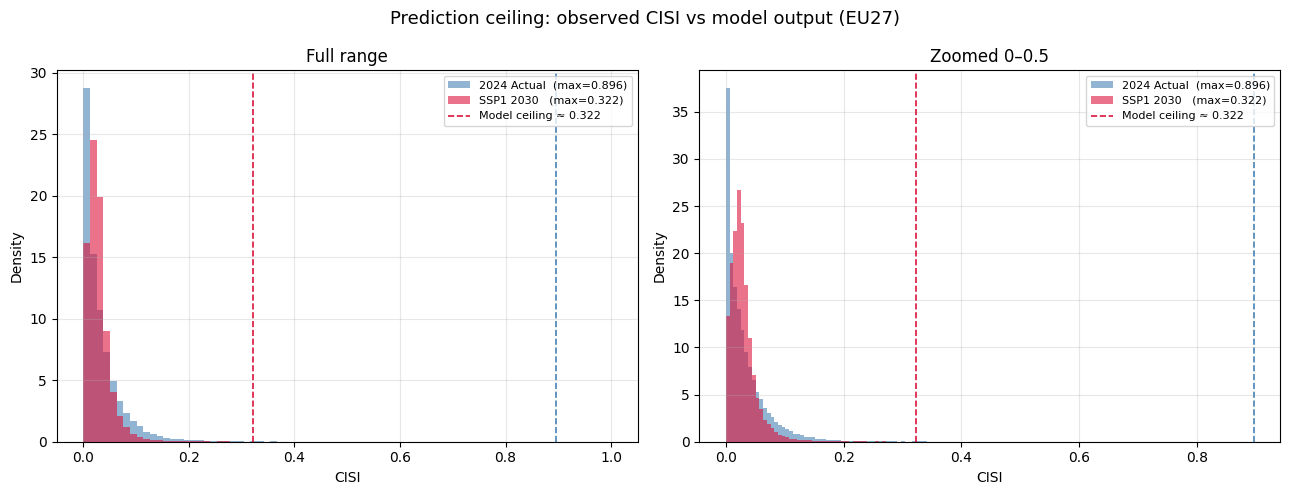

Actual max: 0.8959 | Model max: 0.3223
Actual % > 0.15: 2.16% | Model % > 0.15: 0.60%


In [102]:
# --- Figure 1: Prediction ceiling ---
# Overlaid histogram of 2024 actual CISI vs SSP1 2030 projection (EU27 pixels only)

with rasterio.open(REFERENCE_RASTER) as src:
    actual = src.read(1).astype(np.float32)

actual_vals = actual[VALID_MASK]
actual_vals = actual_vals[~np.isnan(actual_vals)]
pred_vals   = results['SSP1'][2030][VALID_MASK]
pred_vals   = pred_vals[~np.isnan(pred_vals)]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Prediction ceiling: observed CISI vs model output (EU27)', fontsize=13)

bins_full  = np.linspace(0, 1.0, 80)
bins_zoom  = np.linspace(0, 0.5, 80)

for ax, bins, title in zip(axes,
                            [bins_full, bins_zoom],
                            ['Full range', 'Zoomed 0–0.5']):
    ax.hist(actual_vals, bins=bins, alpha=0.6, color='steelblue',
            label=f'2024 Actual  (max={actual_vals.max():.3f})', density=True)
    ax.hist(pred_vals,   bins=bins, alpha=0.6, color='crimson',
            label=f'SSP1 2030   (max={pred_vals.max():.3f})', density=True)
    ax.axvline(actual_vals.max(), color='steelblue', linestyle='--', linewidth=1.2)
    ax.axvline(pred_vals.max(),   color='crimson',   linestyle='--', linewidth=1.2,
               label=f'Model ceiling ≈ {pred_vals.max():.3f}')
    ax.set_xlabel('CISI'); ax.set_ylabel('Density')
    ax.set_title(title); ax.legend(fontsize=8); ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/diagnostic_prediction_ceiling.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Actual max: {actual_vals.max():.4f} | Model max: {pred_vals.max():.4f}')
print(f'Actual % > 0.15: {(actual_vals > 0.15).mean()*100:.2f}% | Model % > 0.15: {(pred_vals > 0.15).mean()*100:.2f}%')

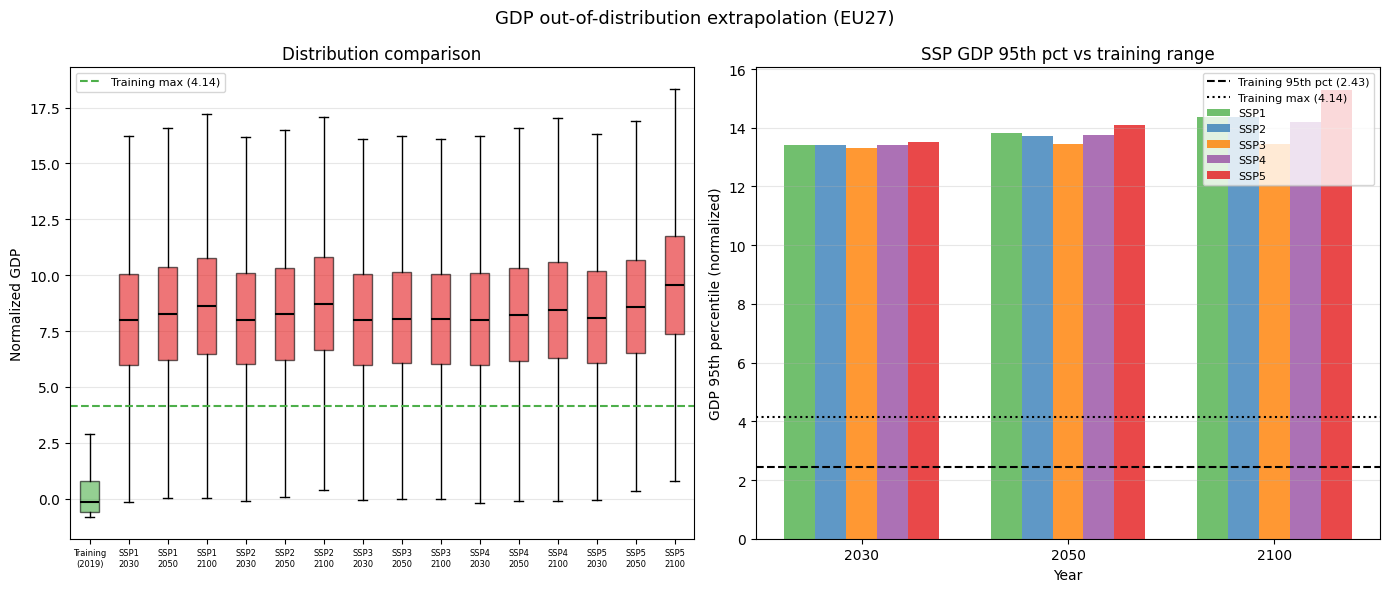

Training GDP   — min: -0.833  max: 4.141  95th: 2.435
SSP1 2030         — min: -0.887  max: 19.491  95th: 13.425
SSP1 2050         — min: -0.887  max: 19.965  95th: 13.818
SSP1 2100         — min: -0.887  max: 20.712  95th: 14.375
SSP2 2030         — min: -0.887  max: 19.457  95th: 13.397
SSP2 2050         — min: -0.887  max: 19.846  95th: 13.720
SSP2 2100         — min: -0.887  max: 20.601  95th: 14.355
SSP3 2030         — min: -0.887  max: 19.387  95th: 13.321
SSP3 2050         — min: -0.887  max: 19.582  95th: 13.433
SSP3 2100         — min: -0.887  max: 19.714  95th: 13.434
SSP4 2030         — min: -0.887  max: 19.467  95th: 13.405
SSP4 2050         — min: -0.887  max: 19.901  95th: 13.736
SSP4 2100         — min: -0.887  max: 20.538  95th: 14.188
SSP5 2030         — min: -0.887  max: 19.567  95th: 13.510
SSP5 2050         — min: -0.887  max: 20.236  95th: 14.092
SSP5 2100         — min: -0.887  max: 21.630  95th: 15.294


In [103]:
# --- Figure 2: GDP out-of-distribution extrapolation ---
# Compare training GDP distribution vs SSP GDP distributions (EU27 pixels)

TRAIN_GDP_PATH = r'READY_data\inputs_normalized\2019_gdp_aligned_010_normalized.tif'

with rasterio.open(TRAIN_GDP_PATH) as src:
    train_gdp = src.read(1).astype(np.float32)
train_gdp_vals = train_gdp[VALID_MASK]
train_gdp_vals = train_gdp_vals[~np.isnan(train_gdp_vals)]

ssp_gdp = {}
for ssp in ['SSP1', 'SSP2', 'SSP3', 'SSP4', 'SSP5']:
    ssp_gdp[ssp] = {}
    for year in [2030, 2050, 2100]:
        path = rf'{NORM_DIR}\GDP_{ssp}_{year}_normalized.tif'
        with rasterio.open(path) as src:
            data = src.read(1).astype(np.float32)
        vals = data[VALID_MASK]
        ssp_gdp[ssp][year] = vals[~np.isnan(vals)]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('GDP out-of-distribution extrapolation (EU27)', fontsize=13)

# Left: box plot of training range vs SSP distributions
ax = axes[0]
labels = ['Training\n(2019)']
data_boxes = [train_gdp_vals]
for ssp in ['SSP1', 'SSP2', 'SSP3', 'SSP4', 'SSP5']:
    for year in [2030, 2050, 2100]:
        labels.append(f'{ssp}\n{year}')
        data_boxes.append(ssp_gdp[ssp][year])

bp = ax.boxplot(data_boxes, patch_artist=True, showfliers=False,
                medianprops=dict(color='black', linewidth=1.5))
for i, patch in enumerate(bp['boxes']):
    patch.set_facecolor('#4daf4a' if i == 0 else '#e41a1c')
    patch.set_alpha(0.6)

train_max = float(train_gdp_vals.max())
ax.axhline(train_max, color='#4daf4a', linestyle='--', linewidth=1.5,
           label=f'Training max ({train_max:.2f})')
ax.set_xticks(range(1, len(labels) + 1))
ax.set_xticklabels(labels, fontsize=6)
ax.set_ylabel('Normalized GDP'); ax.set_title('Distribution comparison')
ax.legend(fontsize=8); ax.grid(alpha=0.3, axis='y')

# Right: 95th percentile of GDP across SSPs × years vs training max
ax = axes[1]
train_p95 = float(np.percentile(train_gdp_vals, 95))
train_max = float(train_gdp_vals.max())

x = np.arange(3)
width = 0.15
colors_ssp = ['#4daf4a', '#377eb8', '#ff7f00', '#984ea3', '#e41a1c']
for i, ssp in enumerate(['SSP1', 'SSP2', 'SSP3', 'SSP4', 'SSP5']):
    p95s = [float(np.percentile(ssp_gdp[ssp][y], 95)) for y in [2030, 2050, 2100]]
    ax.bar(x + i * width, p95s, width, label=ssp, color=colors_ssp[i], alpha=0.8)

ax.axhline(train_p95, color='black', linestyle='--', linewidth=1.5,
           label=f'Training 95th pct ({train_p95:.2f})')
ax.axhline(train_max, color='black', linestyle=':',  linewidth=1.5,
           label=f'Training max ({train_max:.2f})')
ax.set_xticks(x + width * 2)
ax.set_xticklabels([2030, 2050, 2100])
ax.set_xlabel('Year'); ax.set_ylabel('GDP 95th percentile (normalized)')
ax.set_title('SSP GDP 95th pct vs training range')
ax.legend(fontsize=8); ax.grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/diagnostic_gdp_ood.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Training GDP   — min: {train_gdp_vals.min():.3f}  max: {train_gdp_vals.max():.3f}  95th: {train_p95:.3f}')
for ssp in ['SSP1', 'SSP2', 'SSP3', 'SSP4', 'SSP5']:
    for year in [2030, 2050, 2100]:
        v = ssp_gdp[ssp][year]
        print(f'{ssp} {year}         — min: {v.min():.3f}  max: {v.max():.3f}  95th: {np.percentile(v,95):.3f}')

In [117]:
import pandas as pd

# Training ceiling
with rasterio.open(r'READY_data\inputs_normalized\2019_gdp_aligned_010_normalized.tif') as src:
    _tg = src.read(1).astype(np.float32)
_tv = _tg[VALID_MASK]; _tv = _tv[np.isfinite(_tv)]
TRAIN_GDP_MAX = float(_tv.max())
TRAIN_GDP_MIN = float(_tv.min())

rows = []
for ssp in ['SSP1', 'SSP2', 'SSP3', 'SSP4', 'SSP5']:
    for year in [2030, 2050, 2100]:
        path = rf'{NORM_DIR}\GDP_{ssp}_{year}_normalized.tif'
        with rasterio.open(path) as src:
            d = src.read(1).astype(np.float32)
        v = d[VALID_MASK]; v = v[np.isfinite(v)]
        n_above = int((v > TRAIN_GDP_MAX).sum())
        pct_above = float((v > TRAIN_GDP_MAX).mean() * 100)
        rows.append({
            'SSP': ssp,
            'Year': year,
            'Min z': round(float(v.min()), 3),
            'Max z': round(float(v.max()), 3),
            'Median z': round(float(np.median(v)), 3),
            'Pixels above ceiling': n_above,
            '% above ceiling': round(pct_above, 1),
        })

df_gdp_ood = pd.DataFrame(rows)

print(f'Training GDP ceiling (max z-score): {TRAIN_GDP_MAX:.3f}')
print(f'Training GDP floor  (min z-score): {TRAIN_GDP_MIN:.3f}')
print()
print(df_gdp_ood.to_string(index=False))
display(df_gdp_ood.style
    .format({'Min z': '{:.3f}', 'Max z': '{:.3f}', 'Median z': '{:.3f}',
             'Pixels above ceiling': '{:,}', '% above ceiling': '{:.1f}%'})
    .background_gradient(subset=['% above ceiling'], cmap='Reds')
    .set_caption(f'GDP OOD extent — training ceiling = {TRAIN_GDP_MAX:.3f} z-score')
)

Training GDP ceiling (max z-score): 4.141
Training GDP floor  (min z-score): -0.833

 SSP  Year  Min z  Max z  Median z  Pixels above ceiling  % above ceiling
SSP1  2030 -0.887 19.491     7.986                 46955             87.4
SSP1  2050 -0.887 19.965     8.277                 47484             88.4
SSP1  2100 -0.887 20.712     8.601                 48019             89.4
SSP2  2030 -0.887 19.457     7.996                 46983             87.4
SSP2  2050 -0.887 19.846     8.250                 47441             88.3
SSP2  2100 -0.887 20.601     8.700                 48206             89.7
SSP3  2030 -0.887 19.387     7.974                 46874             87.2
SSP3  2050 -0.887 19.582     8.058                 47002             87.5
SSP3  2100 -0.887 19.714     8.051                 46957             87.4
SSP4  2030 -0.887 19.467     7.981                 46973             87.4
SSP4  2050 -0.887 19.901     8.218                 47399             88.2
SSP4  2100 -0.887 20.538   

,SSP,Year,Min z,Max z,Median z,Pixels above ceiling,% above ceiling
0,SSP1,2030,-0.887,19.491,7.986,"46,955",87.4%
1,SSP1,2050,-0.887,19.965,8.277,"47,484",88.4%
2,SSP1,2100,-0.887,20.712,8.601,"48,019",89.4%
3,SSP2,2030,-0.887,19.457,7.996,"46,983",87.4%
4,SSP2,2050,-0.887,19.846,8.250,"47,441",88.3%
5,SSP2,2100,-0.887,20.601,8.700,"48,206",89.7%
6,SSP3,2030,-0.887,19.387,7.974,"46,874",87.2%
7,SSP3,2050,-0.887,19.582,8.058,"47,002",87.5%
8,SSP3,2100,-0.887,19.714,8.051,"46,957",87.4%
9,SSP4,2030,-0.887,19.467,7.981,"46,973",87.4%


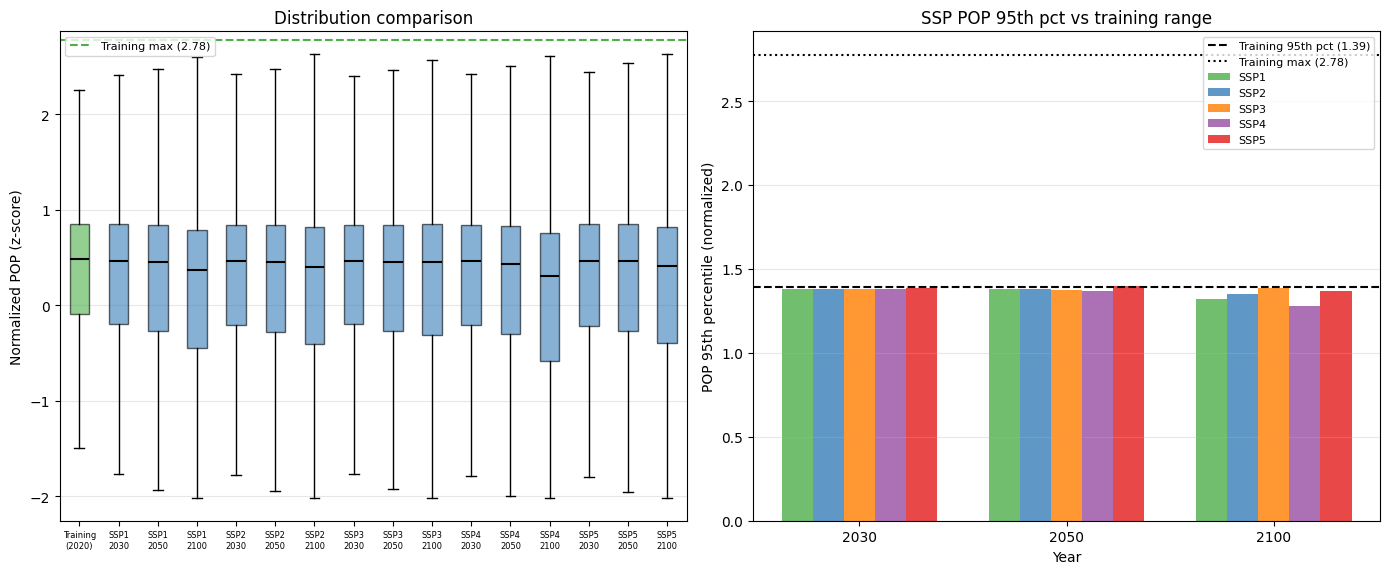

Training POP   — min: -2.024  max: 2.776  95th: 1.390
SSP1 2030         — min: -2.024  max: 2.775  95th: 1.381
SSP1 2050         — min: -2.024  max: 2.793  95th: 1.381
SSP1 2100         — min: -2.024  max: 2.797  95th: 1.323
SSP2 2030         — min: -2.024  max: 2.774  95th: 1.381
SSP2 2050         — min: -2.024  max: 2.793  95th: 1.378
SSP2 2100         — min: -2.024  max: 2.821  95th: 1.351
SSP3 2030         — min: -2.024  max: 2.774  95th: 1.380
SSP3 2050         — min: -2.024  max: 2.796  95th: 1.374
SSP3 2100         — min: -2.024  max: 2.888  95th: 1.383
SSP4 2030         — min: -2.024  max: 2.771  95th: 1.379
SSP4 2050         — min: -2.024  max: 2.774  95th: 1.366
SSP4 2100         — min: -2.024  max: 2.764  95th: 1.280
SSP5 2030         — min: -2.024  max: 2.778  95th: 1.386
SSP5 2050         — min: -2.024  max: 2.806  95th: 1.396
SSP5 2100         — min: -2.024  max: 2.827  95th: 1.369


In [116]:
# --- Figure 2b: POP in-distribution verification ---
# Compare training POP distribution vs SSP POP distributions (EU27 pixels)

TRAIN_POP_PATH_DIAG = r'READY_data\inputs_normalized\2020_pop_aligned_010_normalized.tif'

with rasterio.open(TRAIN_POP_PATH_DIAG) as src:
    train_pop_diag = src.read(1).astype(np.float32)
train_pop_vals = train_pop_diag[VALID_MASK]
train_pop_vals = train_pop_vals[~np.isnan(train_pop_vals)]

ssp_pop = {}
for ssp in ['SSP1', 'SSP2', 'SSP3', 'SSP4', 'SSP5']:
    ssp_pop[ssp] = {}
    for year in [2030, 2050, 2100]:
        path = rf'{NORM_DIR}\POP_{ssp}_{year}_normalized.tif'
        with rasterio.open(path) as src:
            data = src.read(1).astype(np.float32)
        vals = data[VALID_MASK]
        ssp_pop[ssp][year] = vals[~np.isnan(vals)]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('', fontsize=13)

# Left: box plot of training range vs SSP distributions
ax = axes[0]
labels = ['Training\n(2020)']
data_boxes = [train_pop_vals]
for ssp in ['SSP1', 'SSP2', 'SSP3', 'SSP4', 'SSP5']:
    for year in [2030, 2050, 2100]:
        labels.append(f'{ssp}\n{year}')
        data_boxes.append(ssp_pop[ssp][year])

bp = ax.boxplot(data_boxes, patch_artist=True, showfliers=False,
                medianprops=dict(color='black', linewidth=1.5))
for i, patch in enumerate(bp['boxes']):
    patch.set_facecolor('#4daf4a' if i == 0 else '#377eb8')
    patch.set_alpha(0.6)

train_max_pop = float(train_pop_vals.max())
ax.axhline(train_max_pop, color='#4daf4a', linestyle='--', linewidth=1.5,
           label=f'Training max ({train_max_pop:.2f})')
ax.set_xticks(range(1, len(labels) + 1))
ax.set_xticklabels(labels, fontsize=6)
ax.set_ylabel('Normalized POP (z-score)'); ax.set_title('Distribution comparison')
ax.legend(fontsize=8); ax.grid(alpha=0.3, axis='y')

# Right: 95th percentile of POP across SSPs × years vs training max
ax = axes[1]
train_p95_pop = float(np.percentile(train_pop_vals, 95))

x = np.arange(3)
width = 0.15
colors_ssp = ['#4daf4a', '#377eb8', '#ff7f00', '#984ea3', '#e41a1c']
for i, ssp in enumerate(['SSP1', 'SSP2', 'SSP3', 'SSP4', 'SSP5']):
    p95s = [float(np.percentile(ssp_pop[ssp][y], 95)) for y in [2030, 2050, 2100]]
    ax.bar(x + i * width, p95s, width, label=ssp, color=colors_ssp[i], alpha=0.8)

ax.axhline(train_p95_pop, color='black', linestyle='--', linewidth=1.5,
           label=f'Training 95th pct ({train_p95_pop:.2f})')
ax.axhline(train_max_pop, color='black', linestyle=':',  linewidth=1.5,
           label=f'Training max ({train_max_pop:.2f})')
ax.set_xticks(x + width * 2)
ax.set_xticklabels([2030, 2050, 2100])
ax.set_xlabel('Year'); ax.set_ylabel('POP 95th percentile (normalized)')
ax.set_title('SSP POP 95th pct vs training range')
ax.legend(fontsize=8); ax.grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/diagnostic_pop_indistribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Training POP   — min: {train_pop_vals.min():.3f}  max: {train_pop_vals.max():.3f}  95th: {train_p95_pop:.3f}')
for ssp in ['SSP1', 'SSP2', 'SSP3', 'SSP4', 'SSP5']:
    for year in [2030, 2050, 2100]:
        v = ssp_pop[ssp][year]
        print(f'{ssp} {year}         — min: {v.min():.3f}  max: {v.max():.3f}  95th: {np.percentile(v,95):.3f}')

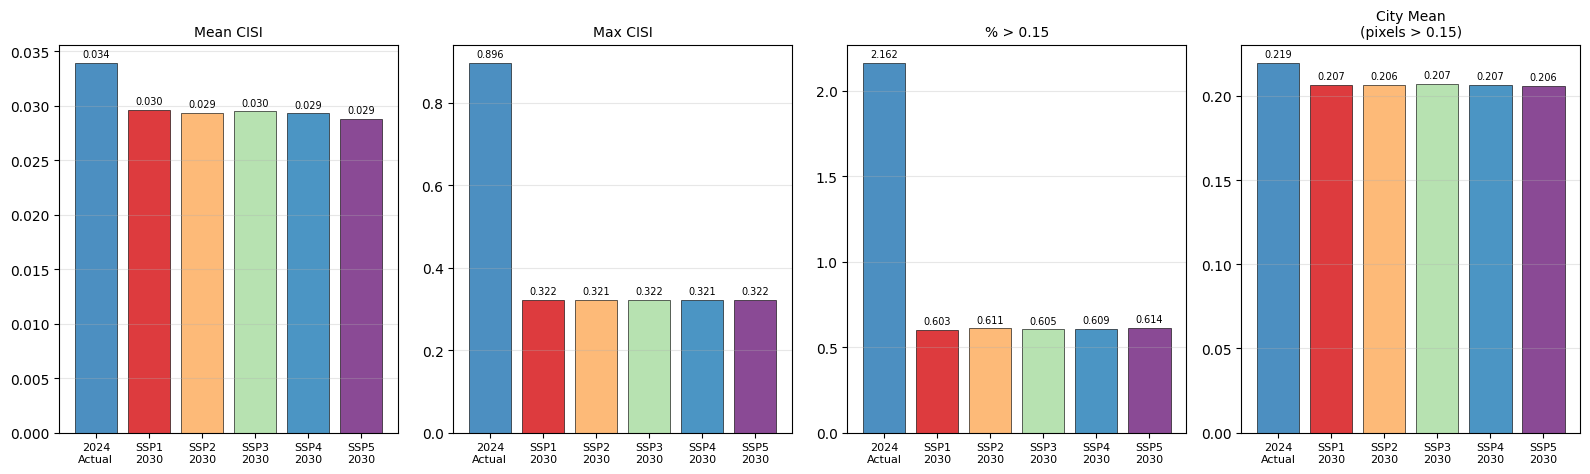

Mean CISI                       2024=0.0339  SSP range=[0.0288, 0.0296]  spread=0.00082
Max CISI                        2024=0.8959  SSP range=[0.3213, 0.3223]  spread=0.00101
% > 0.15                        2024=2.1619  SSP range=[0.6031, 0.6142]  spread=0.01117
City Mean (pixels > 0.15)       2024=0.2195  SSP range=[0.2058, 0.2073]  spread=0.00148


In [115]:
# --- Figure 3: Scenario indistinguishability ---
# Bar chart of key metrics across 2024 actual + all SSP 2030 projections

import pandas as pd

metrics = {
    'Mean CISI':    [],
    'Max CISI':     [],
    '% > 0.15':     [],
    'City Mean\n(pixels > 0.15)': [],
}
labels = []

with rasterio.open(REFERENCE_RASTER) as src:
    actual_full = src.read(1).astype(np.float32)

for label, arr in [('2024\nActual', actual_full)] + [(ssp + '\n2030', results[ssp][2030]) for ssp in SSPS]:
    vals = arr[VALID_MASK]
    vals = vals[~np.isnan(vals)]
    city = vals[vals > 0.15]
    metrics['Mean CISI'].append(float(vals.mean()))
    metrics['Max CISI'].append(float(vals.max()))
    metrics['% > 0.15'].append(float((vals > 0.15).mean() * 100))
    metrics['City Mean\n(pixels > 0.15)'].append(float(city.mean()) if len(city) > 0 else 0.0)
    labels.append(label)

fig, axes = plt.subplots(1, 4, figsize=(16, 5))
fig.suptitle('', fontsize=12)

bar_colors = ['#2c7bb6'] + ['#d7191c', '#fdae61', '#abdda4', '#2b83ba', '#762a83']

for ax, (metric, values) in zip(axes, metrics.items()):
    bars = ax.bar(range(len(labels)), values, color=bar_colors, alpha=0.85, edgecolor='black', linewidth=0.5)
    ax.set_xticks(range(len(labels)))
    ax.set_xticklabels(labels, fontsize=8)
    ax.set_title(metric, fontsize=10)
    ax.grid(alpha=0.3, axis='y')
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(values)*0.01,
                f'{val:.3f}', ha='center', va='bottom', fontsize=7)

plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/diagnostic_scenario_indistinguishability.png', dpi=150, bbox_inches='tight')
plt.show()

# Print range across SSP scenarios
for metric, values in metrics.items():
    ssp_vals = values[1:]
    print(f'{metric.replace(chr(10)," "):<30}  2024={values[0]:.4f}  '
          f'SSP range=[{min(ssp_vals):.4f}, {max(ssp_vals):.4f}]  '
          f'spread={max(ssp_vals)-min(ssp_vals):.5f}')

## Feature importance analysis

Three complementary methods applied to the 2024 (training-era) EU27 input data:
- **Channel ablation**: zero out one channel group, measure mean absolute prediction change vs baseline
- **Permutation importance**: spatially shuffle one channel group (×3 repeats, averaged), measure prediction change
- **Gradient saliency**: mean |∂output/∂input| per channel via backpropagation

Channel layout: 0=GDP, 1=POP, 2–8=LC classes (Water, Forest, Grassland, Barren, Cropland, Urban, Snow/Ice)

In [110]:
# Load 2024 (training-era) input stack
TRAIN_GDP_PATH = r'READY_data\inputs_normalized\2019_gdp_aligned_010_normalized.tif'
TRAIN_POP_PATH = r'READY_data\inputs_normalized\2020_pop_aligned_010_normalized.tif'
TRAIN_LC_PATH  = r'READY_data\landuse_onehot\clipped_history_2020_onehot.tif'

with rasterio.open(TRAIN_GDP_PATH) as src:
    gdp_2024 = src.read(1).astype(np.float32)
with rasterio.open(TRAIN_POP_PATH) as src:
    pop_2024 = src.read(1).astype(np.float32)
with rasterio.open(TRAIN_LC_PATH) as src:
    lc_2024 = src.read().astype(np.float32)  # (n_lc_bands, H, W)

print(f'GDP: {gdp_2024.shape}  POP: {pop_2024.shape}  LC: {lc_2024.shape}')

input_stack_2024 = np.concatenate([
    gdp_2024[np.newaxis],
    pop_2024[np.newaxis],
    lc_2024,
], axis=0)
input_stack_2024 = np.nan_to_num(input_stack_2024, nan=0.0)
print(f'Full input stack: {input_stack_2024.shape}  (channels: GDP, POP, LC×{lc_2024.shape[0]})')

baseline_pred = predict_raster(input_stack_2024)
baseline_vals = baseline_pred[VALID_MASK]
print(f'Baseline — mean: {np.nanmean(baseline_vals):.4f}  max: {np.nanmax(baseline_vals):.4f}')

GDP: (485, 570)  POP: (485, 570)  LC: (7, 485, 570)
Full input stack: (9, 485, 570)  (channels: GDP, POP, LC×7)
Baseline — mean: 0.0338  max: 0.2703


In [111]:
# Channel ablation + permutation importance
import numpy as np

n_lc = lc_2024.shape[0]
LC_NAMES = ['Water', 'Forest', 'Grassland', 'Barren', 'Cropland', 'Urban', 'Snow/Ice'][:n_lc]

CH_GROUPS = {'GDP': [0], 'POP': [1], 'LC (all)': list(range(2, 2 + n_lc))}
for i, name in enumerate(LC_NAMES):
    CH_GROUPS[f'LC-{name}'] = [2 + i]

N_PERMS = 3
np.random.seed(42)

ablation_scores    = {}
permutation_scores = {}

base = baseline_pred[VALID_MASK]

for group, channels in CH_GROUPS.items():
    print(f'{group}...', end=' ', flush=True)

    # Ablation
    s = input_stack_2024.copy()
    for c in channels:
        s[c] = 0.0
    abl_vals = predict_raster(s)[VALID_MASK]
    ablation_scores[group] = float(np.nanmean(np.abs(base - abl_vals)))

    # Permutation
    diffs = []
    for _ in range(N_PERMS):
        s = input_stack_2024.copy()
        for c in channels:
            flat = s[c].flatten()
            np.random.shuffle(flat)
            s[c] = flat.reshape(s[c].shape)
        perm_vals = predict_raster(s)[VALID_MASK]
        diffs.append(float(np.nanmean(np.abs(base - perm_vals))))
    permutation_scores[group] = float(np.mean(diffs))

    print(f'ablation={ablation_scores[group]:.5f}  permutation={permutation_scores[group]:.5f}')

print('\nDone.')

GDP... ablation=0.01327  permutation=0.01418
POP... ablation=0.01503  permutation=0.01556
LC (all)... ablation=0.01011  permutation=0.00642
LC-Water... ablation=0.00015  permutation=0.00234
LC-Forest... ablation=0.00646  permutation=0.00561
LC-Grassland... ablation=0.00518  permutation=0.00467
LC-Barren... ablation=0.00181  permutation=0.00204
LC-Cropland... ablation=0.00113  permutation=0.00121
LC-Urban... ablation=0.00019  permutation=0.00115
LC-Snow/Ice... ablation=0.00055  permutation=0.00099

Done.


In [112]:
# Gradient-based saliency — mean |∂output/∂input| per channel
H, W   = REF_SHAPE
valid_idx = np.argwhere(VALID_MASK)

all_patches = []
for i, j in valid_idx:
    pad_top    = max(0, HALF - i);    pad_bottom = max(0, (i + HALF) - H)
    pad_left   = max(0, HALF - j);    pad_right  = max(0, (j + HALF) - W)
    i0 = max(0, i - HALF);            i1 = min(H, i + HALF)
    j0 = max(0, j - HALF);            j1 = min(W, j + HALF)
    patch = input_stack_2024[:, i0:i1, j0:j1].copy()
    if pad_top or pad_bottom or pad_left or pad_right:
        patch = np.pad(patch, ((0,0),(pad_top,pad_bottom),(pad_left,pad_right)), mode='edge')
    all_patches.append(patch)

n_ch = input_stack_2024.shape[0]
channel_grads = np.zeros(n_ch, dtype=np.float64)
BATCH = 512

projection_model.eval()
for start in range(0, len(all_patches), BATCH):
    batch_np = np.stack(all_patches[start:start + BATCH])
    batch    = torch.FloatTensor(batch_np).to(device)
    batch.requires_grad_(True)
    out = projection_model(batch)
    out.mean().backward()
    grads = batch.grad.detach().abs().mean(dim=(0, 2, 3)).cpu().numpy()
    channel_grads += grads * len(batch_np)

channel_grads /= len(all_patches)

saliency_scores = {'GDP': float(channel_grads[0]), 'POP': float(channel_grads[1]),
                   'LC (all)': float(channel_grads[2:].mean())}
for i, name in enumerate(LC_NAMES):
    saliency_scores[f'LC-{name}'] = float(channel_grads[2 + i])

print('Gradient saliency (mean |∂output/∂input|):')
for k, v in saliency_scores.items():
    print(f'  {k:<15}: {v:.6f}')

Gradient saliency (mean |∂output/∂input|):
  GDP            : 0.000002
  POP            : 0.000002
  LC (all)       : 0.000001
  LC-Water       : 0.000000
  LC-Forest      : 0.000001
  LC-Grassland   : 0.000001
  LC-Barren      : 0.000001
  LC-Cropland    : 0.000001
  LC-Urban       : 0.000001
  LC-Snow/Ice    : 0.000001


     Channel   Ablation  Permutation   Gradient
         GDP 1.3269e-02   1.4183e-02 1.5865e-06
         POP 1.5027e-02   1.5559e-02 1.5807e-06
    LC (all) 1.0112e-02   6.4223e-03 8.8074e-07
    LC-Water 1.4804e-04   2.3358e-03 2.2940e-07
   LC-Forest 6.4609e-03   5.6116e-03 1.0489e-06
LC-Grassland 5.1824e-03   4.6743e-03 1.1328e-06
   LC-Barren 1.8118e-03   2.0408e-03 1.0153e-06
 LC-Cropland 1.1344e-03   1.2058e-03 1.0261e-06
    LC-Urban 1.8807e-04   1.1497e-03 8.5178e-07
 LC-Snow/Ice 5.4616e-04   9.9168e-04 8.6087e-07


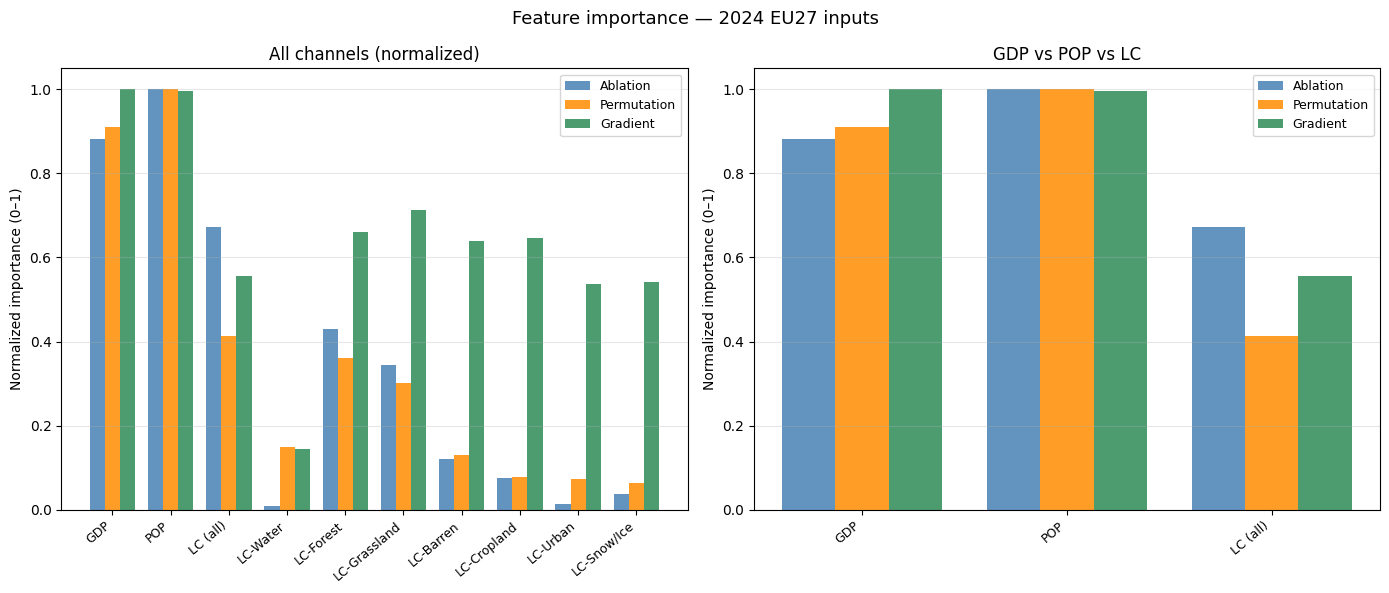

In [113]:
# Summary figure — all three methods side by side
import pandas as pd

groups_all = ['GDP', 'POP', 'LC (all)'] + [f'LC-{n}' for n in LC_NAMES]

df_fi = pd.DataFrame({
    'Channel':     groups_all,
    'Ablation':    [ablation_scores[g]    for g in groups_all],
    'Permutation': [permutation_scores[g] for g in groups_all],
    'Gradient':    [saliency_scores[g]    for g in groups_all],
})
for col in ['Ablation', 'Permutation', 'Gradient']:
    df_fi[col + '_n'] = df_fi[col] / df_fi[col].max()

# Print with scientific notation so small gradient values are visible
print(df_fi[['Channel', 'Ablation', 'Permutation', 'Gradient']].to_string(
    index=False, float_format=lambda x: f'{x:.4e}'))

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Feature importance — 2024 EU27 inputs', fontsize=13)

x_all  = np.arange(len(groups_all))
x_top  = np.arange(3)
w = 0.26

for ax, x, groups, title in [
    (axes[0], x_all, groups_all, 'All channels (normalized)'),
    (axes[1], x_top, ['GDP', 'POP', 'LC (all)'], 'GDP vs POP vs LC'),
]:
    df_sub = df_fi[df_fi['Channel'].isin(groups)].set_index('Channel').loc[groups]
    ax.bar(x - w, df_sub['Ablation_n'],    w, label='Ablation',    color='steelblue',  alpha=0.85)
    ax.bar(x,     df_sub['Permutation_n'], w, label='Permutation', color='darkorange', alpha=0.85)
    ax.bar(x + w, df_sub['Gradient_n'],    w, label='Gradient',    color='seagreen',   alpha=0.85)
    ax.set_xticks(x)
    ax.set_xticklabels(groups, rotation=40, ha='right', fontsize=9)
    ax.set_ylabel('Normalized importance (0–1)')
    ax.set_title(title); ax.legend(fontsize=9); ax.grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()